<a href="https://colab.research.google.com/github/aditi-govindu/DA6002W_end_term_project/blob/main/DA25G501_ORL_end_term_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Online Reinforcement and Learning end term project

* Name: Aditi Govindu
* Roll no: DA25G501

# Setup from [starter code.ipynb](/content/drive/MyDrive/orl_end_term_project/starter_notebook.ipynb) as it is

In [1]:
!pip install -r /content/drive/MyDrive/orl_end_term_project/requirements.txt

In [2]:
# @title Imports and setup
from copy import deepcopy
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from torch.distributions import Categorical
import multiprocessing

ROLL_NUMBER = 'DA25G501'
SEED = 2026

N = 3
TRAINING_EPISODES = 25000
V_max = 1000.0
v = np.array([2.0, 3.0, 1.5])
c_h = 5.00
c_s = np.array([400.0, 500.0, 300.0])
c_o = np.array([80.0, 200.0, 120.0])
c_d = np.array([200.0, 250.0, 150.0])
L = np.array([3, 2, 1])
mu_d = np.array([30, 25, 35])
T = 50 # No. of episodes capped to 50

In [3]:
# @title Setup from starter code.

# Add the parent directory to sys.path to import industrial_inventory_env.
sys.path.append('/content/drive/MyDrive/orl_end_term_project')

from industrial_inventory_env import (
    IndustrialInventoryEnv,
    generate_student_config,
    public_config_summary,
)

np.set_printoptions(suppress=True)
print('Imports completed.')

student_config = generate_student_config(ROLL_NUMBER)
config_summary = public_config_summary(student_config)

print('Assigned configuration generated successfully.')
for key, value in config_summary.items():
    print(f'{key}: {value}')

Imports completed.
Assigned configuration generated successfully.
project_version: IITM-6002W-RL-Inventory-2026-v1
roll_number: DA25G501
variant_id: V015
config_fingerprint: d018ef2f72ad80b9
demand_multiplier_profile: [1.0, 0.85, 1.15]
initial_inventory_profile: [80, 100, 120]
lead_time_delay_profile: [0.05, 0.1, 0.0]


In [4]:
# @title Environment setup from starter code.
env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode='random',
    domain_randomization=True,
)

observation, info = env.reset(seed=SEED)

print('Action space:', env.action_space)
print('Observation space:', env.observation_space)
print('Variant:', info['variant_id'])
print('Scenario components:', info['episode_parameters']['scenario_components'])
print('Episode demand multipliers:', info['episode_parameters']['demand_multipliers'])
print('Episode initial inventory:', info['episode_parameters']['initial_inventory'])
print('Episode delay probabilities:', info['episode_parameters']['delay_probabilities'])

Action space: MultiDiscrete([11 11 11])
Observation space: Dict('arrival_pipeline': Box(0, 10000, (3, 4), int32), 'capacity_utilisation': Box(0.0, 1.0, (1,), float32), 'day': Box(0, 50, (1,), int32), 'demand_history': Box(0, 10000, (7, 3), int32), 'inventory': Box(0, 1000, (3,), int32))
Variant: V015
Scenario components: ['seasonal', 'trend']
Episode demand multipliers: [1.05, 0.85, 1.0999999999999999]
Episode initial inventory: [80, 100, 120]
Episode delay probabilities: [0.030000000000000002, 0.1, 0.0]


In [5]:
# @title Observations and Actions from starter code.
for key, value in observation.items():
    print(f'{key:22s} shape={value.shape}, dtype={value.dtype}')
    print(value)
    print()

order_quantities = [40, 20, 0]
action_indices = env.quantities_to_action_indices(order_quantities)

print('Actual order quantities:', order_quantities)
print('Internal action indices:', action_indices.tolist())
print('Converted back:', env.action_indices_to_quantities(action_indices).tolist())

inventory              shape=(3,), dtype=int32
[ 80 100 120]

arrival_pipeline       shape=(3, 4), dtype=int32
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]

demand_history         shape=(7, 3), dtype=int32
[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]

day                    shape=(1,), dtype=int32
[0]

capacity_utilisation   shape=(1,), dtype=float32
[0.64]

Actual order quantities: [40, 20, 0]
Internal action indices: [4, 2, 0]
Converted back: [40, 20, 0]


In [6]:
# @title Example of a single interaction.
next_observation, reward, terminated, truncated, step_info = env.step(action_indices)

print('Reward:', reward)
print('Terminated:', terminated)
print('Truncated:', truncated)
print('Demand:', step_info['demand'])
print('Daily costs:', step_info['costs'])
print('Next inventory:', next_observation['inventory'])

Reward: -26.9
Terminated: False
Truncated: False
Demand: [34 16 28]
Daily costs: {'holding': 2410.0, 'stockout': 0.0, 'ordering': 280.0, 'discarding': 0.0, 'daily_total': 2690.0, 'episode_total': 2690.0}
Next inventory: [46 84 92]


In [7]:
# @title Dummy policy. NOT counted towards 5 policies needed to submit.

def demonstration_policy(observation: dict) -> list[int]:
    'Simple deterministic inventory-position heuristic for demonstration.'
    inventory = np.asarray(observation['inventory'], dtype=float)
    pipeline = np.asarray(observation['arrival_pipeline'], dtype=float)
    inventory_position = inventory + pipeline.sum(axis=1)

    targets = np.asarray([110.0, 100.0, 120.0])
    required = np.maximum(targets - inventory_position, 0.0)
    quantities = np.clip(np.ceil(required / 10.0) * 10.0, 0.0, 100.0)
    return quantities.astype(int).tolist()

# Running a deterministic episode with the code to test dummy policy.
demo_env = IndustrialInventoryEnv(
    student_config,
    scenario_mode='random',
    domain_randomization=True,
)
observation, reset_info = demo_env.reset(seed=SEED)

records = []
while True:
    quantities = demonstration_policy(observation)
    action = demo_env.quantities_to_action_indices(quantities)
    observation, reward, terminated, truncated, info = demo_env.step(action)

    records.append(
        {
            'day': info['day'],
            'reward': reward,
            'daily_cost': info['costs']['daily_total'],
            'episode_cost': info['costs']['episode_total'],
            'inventory_p1': int(observation['inventory'][0]),
            'inventory_p2': int(observation['inventory'][1]),
            'inventory_p3': int(observation['inventory'][2]),
            'order_p1': int(quantities[0]),
            'order_p2': int(quantities[1]),
            'order_p3': int(quantities[2]),
        }
    )

    if terminated or truncated:
        break

one_episode_results = pd.DataFrame(records)
print('Episode days:', len(one_episode_results))
print('Total episode cost:', one_episode_results['daily_cost'].sum())
one_episode_results.head()

Episode days: 50
Total episode cost: 133675.0


,day,reward,daily_cost,episode_cost,inventory_p1,inventory_p2,inventory_p3,order_p1,order_p2,order_p3
0,0,-24.900,2490.0,2490.0,46,84,92,30,0,0
1,1,-19.875,1987.5,4477.5,17,66,57,40,20,30
2,2,-53.450,5345.0,9822.5,0,43,40,30,20,40
3,3,-14.225,1422.5,11245.0,1,44,47,10,20,40
4,4,-15.625,1562.5,12807.5,9,44,55,30,20,40


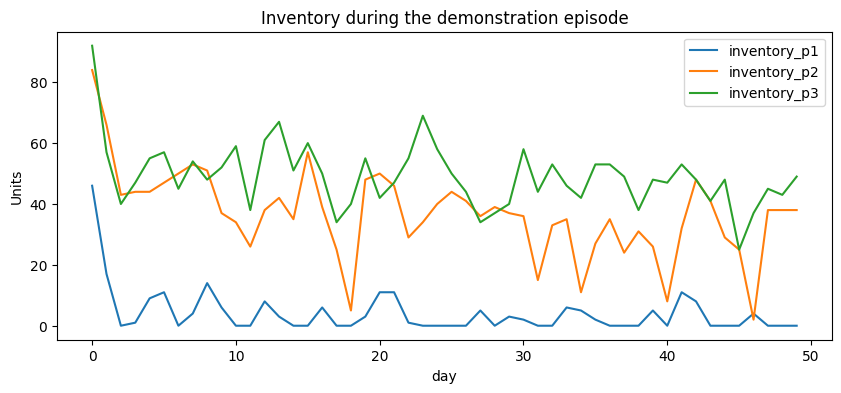

In [8]:
# @title Plot dummy policy results.
one_episode_results.plot(
    x='day',
    y=['inventory_p1', 'inventory_p2', 'inventory_p3'],
    figsize=(10, 4),
    title='Inventory during the demonstration episode',
)
plt.ylabel('Units')
plt.show()

In [9]:
# @title Actions and product configs

def preprocess_observation(obs):
    inv = obs['inventory'] / 1000.0  # Normalize inventory
    pipeline = obs['arrival_pipeline'].flatten() / 100.0  # Normalize 3x4 pipeline
    demand_hist = obs['demand_history'].flatten() / 100.0  # Normalize 7x3 demand
    day = np.array([obs['day'] / 50.0])  # Normalize day
    cap = np.array([obs['capacity_utilisation']]) # Already normalized 0-1

    return np.concatenate([inv, pipeline, demand_hist, day, cap], axis=0)

# Translation helpers between RL Discrete/MultiDiscrete indices and policy quantities
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

def action_index_to_quantity(action_indices):
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

def quantity_to_action_index(quantities):
    'Convert actual quantities [q1, q2, q3] back to internal indices (0-10)'
    return [int(q // 10) for q in quantities]

# Project by DA25G501

In [10]:
# @title Local validation loop

def evaluate_policy(
    policy,
    student_config,
    num_episodes: int = 20,
    scenario_modes: list[str] = None,
    domain_randomization: bool = True,
    seeds: list[int] = None,
) -> pd.DataFrame:
    'Evaluates a given policy over multiple episodes and returns performance metrics.'

    if scenario_modes is None:
        scenario_modes = ['random']
    if seeds is None:
        # Generate reproducible seeds if not provided.
        np.random.seed(42)  # Master seed for reproducibility of evaluation.
        seeds = np.random.randint(0, 100000, num_episodes)

    all_episode_costs = []
    all_daily_stockout_events = []
    all_daily_discard_events = []

    for i in range(num_episodes):
        # Cycle through scenario modes if more episodes than modes.
        current_scenario_mode = scenario_modes[i % len(scenario_modes)]
        current_seed = seeds[i]

        # Store same environment as original one assigned to DA25G501.
        env = IndustrialInventoryEnv(
            student_config=student_config,
            scenario_mode=current_scenario_mode,
            domain_randomization=domain_randomization,
        )

        # Cast current_seed to a standard Python integer
        observation, _ = env.reset(seed=int(current_seed))

        episode_daily_costs = []
        # Boolean to store 1 if stockout occurred on that day, 0 otherwise.
        episode_stockout_events = []
        # Boolean array keeps 1 if discarding occurred on that day, 0 otherwise.
        episode_discard_events = []

        terminated = False
        truncated = False
        while not terminated and not truncated:
            quantities = policy(observation)
            action = env.quantities_to_action_indices(quantities)
            observation, reward, terminated, truncated, info = env.step(action)

            episode_daily_costs.append(info['costs']['daily_total'])

            # Check for stockout event: total unfulfilled demand > 0.
            stockout_happened = 1 if info['unfulfilled_demand'].sum() > 0 else 0
            episode_stockout_events.append(stockout_happened)

            # Check for discard event: discarding cost > 0.
            discard_happened = 1 if info['costs']['discarding'] > 0 else 0
            episode_discard_events.append(discard_happened)

        all_episode_costs.append(sum(episode_daily_costs))
        all_daily_stockout_events.extend(episode_stockout_events)
        all_daily_discard_events.extend(episode_discard_events)

    # Calculate metrics
    M = num_episodes
    # Run loop for 50 days.
    total_days = T * M

    mean_episode_cost = np.mean(all_episode_costs)
    cost_std_dev = np.std(all_episode_costs)
    stockout_frequency = np.sum(all_daily_stockout_events) / total_days
    discard_event_rate = np.sum(all_daily_discard_events) / total_days

    results = pd.DataFrame({
        'Mean Episode Cost': [mean_episode_cost],
        'Cost Standard Deviation': [cost_std_dev],
        'Stockout Frequency': [stockout_frequency],
        'Capacity Discard Event Rate': [discard_event_rate],
    })

    return results


In [11]:
def calculate_costs_and_reward(
    inventory: np.ndarray, # I_{i,t} on-hand inventory after serving demand
    inventory_available: np.ndarray, # I_{i,t}^available on-hand stock prior to fulfillment
    demand: np.ndarray, # D_{i,t} realized demand
    orders: np.ndarray, # q_{i,t} ordered quantities
    discarded_units: np.ndarray, # K_{i,t} allocated discard quantities
) -> dict:
    '''Calculates various cost components and the base reward based on environment state and actions.

    Args:
        inventory: Current on-hand inventory per product after serving demand.
        inventory_available: On-hand stock prior to demand fulfillment.
        demand: Realized demand for each product.
        orders: Ordered quantities for each product.
        discarded_units: Quantities of each product discarded due to capacity limits.

    Returns:
        A dictionary containing holding, stockout, ordering, discarding, daily total costs, and the base reward.
    '''

    # Holding Cost (C_h_t) - amount spent to save current inventory.
    V_t = np.sum(v * inventory)
    C_h_t = V_t * c_h

    # Stockout Cost (C_s_t) - wastage cost due to dead inventory.
    C_s_t = np.sum(c_s * np.maximum(0, demand - inventory_available))

    # Ordering Cost (C_o_t) - cost to order more items if not available.
    # np.sum(orders > 0) counts the number of products for which orders > 0
    C_o_t = np.sum(c_o * (orders > 0).astype(int))

    # Discarding Cost (C_d_t) - wastage cost due to unsold items.
    C_d_t = np.sum(c_d * discarded_units)

    # Total Daily Cost & Official Base Reward
    Daily_Cost_t = C_h_t + C_s_t + C_o_t + C_d_t
    R_base_t = -Daily_Cost_t / 100.0

    return {
        'holding_cost': C_h_t,
        'stockout_cost': C_s_t,
        'ordering_cost': C_o_t,
        'discarding_cost': C_d_t,
        'daily_total_cost': Daily_Cost_t,
        'base_reward': R_base_t,
    }

In [12]:
# @title Continuous State Normalization (Deep RL Input Layer)
def continuous_state_normalization(obs: dict) -> np.ndarray:
    '''Normalizes and flattens the raw observation dictionary into a continuous vector.

    Args:
        obs: The raw observation dictionary from the environment.

    Returns:
        A numpy array representing the normalized continuous state vector.
    '''
    # I_t / 500.0
    inventory_norm = obs['inventory'].astype(float) / 500.0
    # vec(P_t) / 200.0
    pipeline_norm = obs['arrival_pipeline'].flatten().astype(float) / 200.0
    # vec(H_t) / 100.0
    demand_history_norm = obs['demand_history'].flatten().astype(float) / 100.0
    # t / 50.0
    day_norm = obs['day'].astype(float) / 50.0
    # U_t (already normalized)
    capacity_utilisation_norm = obs['capacity_utilisation'].astype(float)

    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)

### Discrete State Aggregation for Tabular RL Input Layer
def discrete_state_aggregation(obs: dict) -> int:
    '''Aggregates continuous state variables into a single discrete state index.

    Args:
        obs: The raw observation dictionary from the environment.

    Returns:
        An integer representing the discrete state index.
    '''

    # Inventory Bins (per product): Low ([0, 30)), Medium ([30, 80)), High (>= 80).
    # (3^3 = 27 states)
    inventory_bins = []
    for i in range(N):
        if obs['inventory'][i] < 30:
            inventory_bins.append(0) # Low
        elif obs['inventory'][i] < 80:
            inventory_bins.append(1) # Medium
        else:
            inventory_bins.append(2) # High
    # Convert base-3 representation to a single integer
    inventory_state = inventory_bins[0] * 9 + inventory_bins[1] * 3 + inventory_bins[2] * 1

    # Total Pipeline Sum Bins (per product): Low ([0, 30)), High (>= 30).
    # (2^3 = 8 states)
    pipeline_bins = []
    for i in range(N):
        total_pipeline_sum = obs['arrival_pipeline'][i].sum()
        if total_pipeline_sum < 30:
            pipeline_bins.append(0) # Low
        else:
            pipeline_bins.append(1) # High
    # Convert base-2 representation to a single integer
    pipeline_state = pipeline_bins[0] * 4 + pipeline_bins[1] * 2 + pipeline_bins[2] * 1

    # Episode Phase: Early (t <= 15), Mid (15 < t <= 35), Late (t > 35).
    # (3 states)
    day = obs['day'][0] # day is a np.array([day_value])
    if day <= 15:
        day_state = 0 # Early
    elif day <= 35:
        day_state = 1 # Mid
    else:
        day_state = 2 # Late

    # Total Tabular State Space Size: 27 * 8 * 3 = 648 state indices.
    # Combined state: inv_state * (8 * 3) + pipe_state * 3 + day_state
    discrete_state = inventory_state * (8 * 3) + pipeline_state * 3 + day_state

    return discrete_state

# Tabular Q-Learning Implementation

Tabular Q-Learning is a model-free reinforcement learning algorithm used to learn the value of state-action pairs. It uses a Q-table to store and update Q-values. The agent learns an optimal policy by interacting with the environment and updating its Q-values based on observed rewards and future maximum Q-values.

**Update Rule:**
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_t + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \right]$$

**Inference Policy:** $A^* = \arg\max_{a} Q(S, a)$

In [13]:
NUM_DISCRETE_STATES = 27 * 8 * 3
NUM_PRODUCTS = N
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES)
NUM_TOTAL_ACTIONS = NUM_CHOICES_PER_PRODUCT ** NUM_PRODUCTS

q_table = np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS))

# Tuning for faster but stable learning
ALPHA = 0.07
GAMMA = 0.96
EPSILON = 1.0
EPSILON_DECAY = 0.995
MIN_EPSILON = 0.01

print(f'Q-table initialized with updated hyperparameters.')

Q-table initialized with updated hyperparameters.


In [14]:
# Helper functions for action mapping to handle the full 1331 action space
def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    '''Converts a single integer action index (0-1330) to a MultiDiscrete action tuple [a1, a2, a3].'''
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def map_multi_discrete_to_action_index(multi_discrete_action: list[int]) -> int:
    'Converts a MultiDiscrete action tuple [a1, a2, a3] to a single integer action index (0-1330).'
    action_idx = 0
    for i, val in enumerate(multi_discrete_action):
        action_idx += val * (NUM_CHOICES_PER_PRODUCT ** (NUM_PRODUCTS - 1 - i))
    return action_idx

# State Discretization based on Inventory Position (IP = Inventory + Pipeline)
def discrete_state_aggregation(obs: dict) -> int:
    inventory = obs['inventory']
    pipeline = obs['arrival_pipeline'].sum(axis=1)
    ip = inventory + pipeline

    # Binning IP1: [0, 50, 90, 130, 200+]
    if ip[0] < 50: b1 = 0
    elif ip[0] < 90: b1 = 1
    elif ip[0] < 130: b1 = 2
    elif ip[0] < 200: b1 = 3
    else: b1 = 4

    # Binning IP2: [0, 40, 75, 110, 180+]
    if ip[1] < 40: b2 = 0
    elif ip[1] < 75: b2 = 1
    elif ip[1] < 110: b2 = 2
    elif ip[1] < 180: b2 = 3
    else: b2 = 4

    # Binning IP3: [0, 30, 60, 90, 150+]
    if ip[2] < 30: b3 = 0
    elif ip[2] < 60: b3 = 1
    elif ip[2] < 90: b3 = 2
    elif ip[2] < 150: b3 = 3
    else: b3 = 4

    # Day phase (3 states)
    day = obs['day'][0]
    d_s = 0 if day <= 15 else (1 if day <= 35 else 2)

    # Total Tabular States: 5 * 5 * 5 * 3 = 375
    return (b1 * 75) + (b2 * 15) + (b3 * 3) + d_s

# Test mapping functions to verify the full 1331 space mapping
test_multi_discrete = [10, 10, 10] # Maximum quantities indices
test_single_index = map_multi_discrete_to_action_index(test_multi_discrete)
print(f'MultiDiscrete action {test_multi_discrete} maps to single index: {test_single_index}')

converted_back = map_action_index_to_multi_discrete(test_single_index)
print(f'Single index {test_single_index} maps back to MultiDiscrete action: {converted_back}')
assert converted_back == test_multi_discrete
assert test_single_index == 1330 # (10 * 121) + (10 * 11) + 10

MultiDiscrete action [10, 10, 10] maps to single index: 1330
Single index 1330 maps back to MultiDiscrete action: [10, 10, 10]


In [15]:
# Expanded action space: Use all 1331 combinations instead of heuristics
NUM_PRODUCTS = 3
NUM_CHOICES_PER_PRODUCT = 11  # 0 to 100 in steps of 10
NUM_TOTAL_ACTIONS = NUM_CHOICES_PER_PRODUCT ** NUM_PRODUCTS  # 1331

# Updated Q-table initialization for the full action space
# State space based on Inventory Position binning: 5 * 5 * 5 * 3 = 375 states
NUM_DISCRETE_STATES = 375
full_q_table = np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS))

print(f"Action space expanded to: {NUM_TOTAL_ACTIONS}")
print(f"Q-table initialized with shape: {full_q_table.shape}")

Action space expanded to: 1331
Q-table initialized with shape: (375, 1331)


In [16]:
def train_q_learning_full_space(
    env: IndustrialInventoryEnv,
    q_table: np.ndarray,
    num_episodes: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    epsilon_decay: float,
    min_epsilon: float,
) -> tuple[np.ndarray, list[float]]:
    '''Trains a Q-Learning agent using the full MultiDiscrete action space.'''
    episode_costs = []
    current_epsilon = epsilon

    observation, _ = env.reset(seed=SEED)

    for episode in range(num_episodes):
        # Use dynamic seeding for training to improve generalization
        if episode > 0:
          observation, _ = env.reset()
        state = discrete_state_aggregation(observation)
        terminated = False
        truncated = False
        episode_total_cost = 0.0

        while not terminated and not truncated:
            # Epsilon-greedy over the FULL action space (0 to 1330)
            if np.random.rand() < current_epsilon:
                action_idx = np.random.randint(0, NUM_TOTAL_ACTIONS)
            else:
                action_idx = np.argmax(q_table[state, :])

            # Map single integer index to MultiDiscrete triplets
            multi_discrete_indices = map_action_index_to_multi_discrete(action_idx)
            quantities = action_index_to_quantity(multi_discrete_indices)
            env_action = env.quantities_to_action_indices(quantities)

            # Interaction
            next_obs, _, terminated, truncated, info = env.step(env_action)
            next_state = discrete_state_aggregation(next_obs)

            # Custom reward calculation (-Cost/100)
            cost_data = calculate_costs_and_reward(
                inventory=next_obs['inventory'],
                inventory_available=observation['inventory'],
                demand=info['demand'],
                orders=np.array(quantities),
                discarded_units=info['discarded_units']
            )
            reward = cost_data['base_reward']
            episode_total_cost += info['costs']['daily_total']

            # Q-update
            max_future_q = 0 if (terminated or truncated) else np.max(q_table[next_state, :])
            q_table[state, action_idx] += alpha * (reward + gamma * max_future_q - q_table[state, action_idx])

            state = next_state
            observation = next_obs

        episode_costs.append(episode_total_cost)
        current_epsilon = max(min_epsilon, current_epsilon * epsilon_decay)

        if (episode + 1) % 500 == 0:
            print(f'Ep {episode+1}/{num_episodes}: Rolling Cost={np.mean(episode_costs[-100:]):.1f}, Eps={current_epsilon:.3f}')

    return q_table, episode_costs

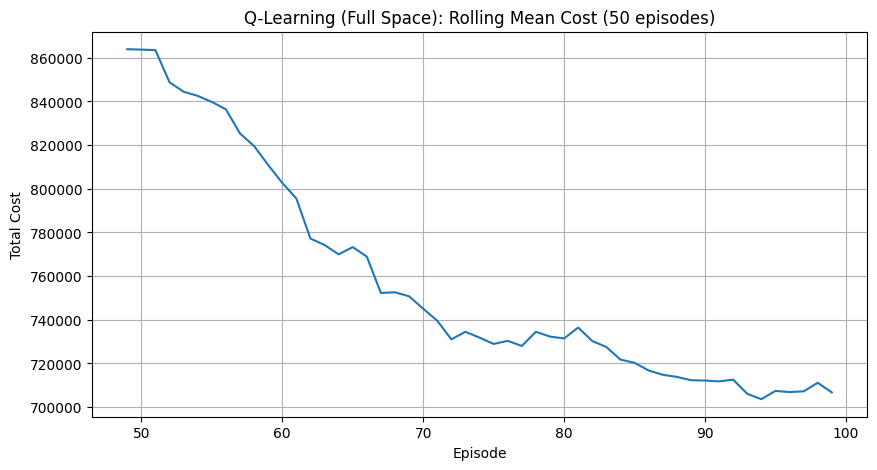

In [17]:
# @title Execute Q-Learning Training (Full Action Space)
training_env_full = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode='random',
    domain_randomization=True,
)

# Run training with the 1331-action table
# Using the full_q_table defined in cell 4f7f634f
trained_full_q_table, full_costs = train_q_learning_full_space(
    env=training_env_full,
    q_table=full_q_table,
    num_episodes=TRAINING_EPISODES,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY,
    min_epsilon=MIN_EPSILON,
)

# Visualize convergence
plt.figure(figsize=(10, 5))
plt.plot(pd.Series(full_costs).rolling(window=50).mean())
plt.title('Q-Learning (Full Space): Rolling Mean Cost (50 episodes)')
plt.xlabel('Episode')
plt.ylabel('Total Cost')
plt.grid(True)
plt.show()

In [18]:
# @title Saving Q-learning model
model_path = 'q_table_trained.npy'
np.save(model_path, trained_full_q_table)
print(f"Trained Tabular Q-learning model saved to {model_path}")

Trained Tabular Q-learning model saved to q_table_trained.npy


In [19]:
# @title Evaluate Q-learning
def q_learning_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained Tabular Q-Learning policy.'
    state = discrete_state_aggregation(observation)
    action_idx = np.argmax(trained_full_q_table[state, :])
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)
    return quantities


# Evaluate the Tabular Q-Learning policy
print('Evaluating Tabular Q-Learning...')
q_learning_results = evaluate_policy(q_learning_policy, student_config)
display(q_learning_results)


Evaluating Tabular Q-Learning...


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,1464074.125,43618.944152,0.957,0.0


In [20]:
# @title Inference using saved Tabular Q-learning model
N = 3 # Number of Products
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = N
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES) # 11 (0 to 100 in steps of 10)
NUM_TOTAL_ACTIONS = NUM_CHOICES_PER_PRODUCT ** NUM_PRODUCTS # 11^3 = 1331
NUM_DISCRETE_STATES = 27 * 8 * 3  # From discrete_state_aggregation (Inventory * Pipeline * DayPhase)

# Helper functions
def discrete_state_aggregation(obs: dict) -> int:
    'Aggregates continuous state variables into a single discrete state index.'
    # Inventory Bins (per product): Low ([0, 30)), Medium ([30, 80)), High (>= 80).
    inventory_bins = []
    for i in range(N):
        if obs['inventory'][i] < 30:
            inventory_bins.append(0) # Low
        elif obs['inventory'][i] < 80:
            inventory_bins.append(1) # Medium
        else:
            inventory_bins.append(2) # High
    inventory_state = inventory_bins[0] * 9 + inventory_bins[1] * 3 + inventory_bins[2] * 1

    # Total Pipeline Sum Bins (per product): Low ([0, 30)), High (>= 30).
    pipeline_bins = []
    for i in range(N):
        total_pipeline_sum = obs['arrival_pipeline'][i].sum()
        if total_pipeline_sum < 30:
            pipeline_bins.append(0) # Low
        else:
            pipeline_bins.append(1) # High
    pipeline_state = pipeline_bins[0] * 4 + pipeline_bins[1] * 2 + pipeline_bins[2] * 1

    # Episode Phase: Early (t <= 15), Mid (15 < t <= 35), Late (t > 35).
    day = obs['day'][0]
    if day <= 15:
        day_state = 0 # Early
    elif day <= 35:
        day_state = 1 # Mid
    else:
        day_state = 2 # Late

    discrete_state = inventory_state * (8 * 3) + pipeline_state * 3 + day_state
    return discrete_state

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    'Converts a single integer action index to a MultiDiscrete action tuple.'
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

# This Q-table will be loaded once when the policy.py module is imported.
initial_q_table = np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS))

# Evaluate the policy.
model_path = Path('./q_table_trained.npy')

if model_path.exists():
    try:
        q_table = np.load(model_path)
        print(f'Q-table loaded successfully from {model_path}')
    except Exception as e:
        print(f'Error loading Q-table from {model_path}: {e}')
        print('Q-table initialized with zeros instead.')
        q_table = initial_q_table
else:
    print(f'Warning: Model file not found at {model_path}. Q-table initialized with zeros.')
    print('Please ensure your trained q_h_table_trained.npy is saved in the correct location.')
    q_table = initial_q_table


# Main evaluation
def run_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained Tabular Q-Learning policy.'

    # Get discrete state from observation
    state = discrete_state_aggregation(observation)

    # Choose action with the highest Q-value (exploitation only)
    action_idx = np.argmax(q_table[state, :])

    # Convert single action index to MultiDiscrete action tuple
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)

    # Convert MultiDiscrete indices to actual quantities
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Test a run
if __name__ == '__main__':
    print('\n--- Testing run_policy function ---')
    dummy_observation = {
        'inventory': np.array([50, 60, 70], dtype=np.int32),
        'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
        'demand_history': np.zeros((7, 3), dtype=np.int32),
        'day': np.array([10], dtype=np.int32),
        'capacity_utilisation': np.array([0.5], dtype=np.float32)
    }
    recommended_quantities = run_policy(dummy_observation)
    print(f'Recommended quantities for dummy observation: {recommended_quantities}')

Q-table loaded successfully from q_table_trained.npy

--- Testing run_policy function ---
Recommended quantities for dummy observation: [0, 0, 10]


# Tabular SARSA
- **Update Rule:**
  $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_t + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \right]$$
- **Inference Policy:** $A^* = \arg\max_{a} Q(S, a)$

In [21]:
# @title Tabular SARSA with Heuristic Action Space (Fixed State Aggregation)

N = 3 # Number of Products
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = N
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES) # 11 (0 to 100 in steps of 10)
NUM_TOTAL_ACTIONS = NUM_CHOICES_PER_PRODUCT ** NUM_PRODUCTS # 11^3 = 1331
NUM_DISCRETE_STATES = 375 # 5 * 5 * 5 * 3 from discrete_state_aggregation_fixed

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    'Converts a single integer action index to a MultiDiscrete action tuple.'
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

def map_heuristic_index_to_quantities(action_idx: int) -> list[int]:
    'Maps a single action index (representing the full action space) to quantities.'
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    return action_index_to_quantity(multi_discrete_action)

def discrete_state_aggregation_fixed(obs: dict) -> int:
    inventory = obs['inventory']
    pipeline = obs['arrival_pipeline'].sum(axis=1)
    ip = inventory + pipeline  # Inventory Position

    # Binning IP1: [0, 50, 90, 130, 200+]
    if ip[0] < 50: b1 = 0
    elif ip[0] < 90: b1 = 1
    elif ip[0] < 130: b1 = 2
    elif ip[0] < 200: b1 = 3
    else: b1 = 4

    # Binning IP2: [0, 40, 75, 110, 180+]
    if ip[1] < 40: b2 = 0
    elif ip[1] < 75: b2 = 1
    elif ip[1] < 110: b2 = 2
    elif ip[1] < 180: b2 = 3
    else: b2 = 4

    # Binning IP3: [0, 30, 60, 90, 150+]
    if ip[2] < 30: b3 = 0
    elif ip[2] < 60: b3 = 1
    elif ip[2] < 90: b3 = 2
    elif ip[2] < 150: b3 = 3
    else: b3 = 4

    # Day phase (3 states)
    day = obs['day'][0]
    d_s = 0 if day <= 15 else (1 if day <= 35 else 2)

    # Total States: 5 * 5 * 5 * 3 = 375
    return (b1 * 75) + (b2 * 15) + (b3 * 3) + d_s

def train_sarsa_heuristic(
    env: IndustrialInventoryEnv,
    q_table: np.ndarray,
    num_episodes: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    epsilon_decay: float,
    min_epsilon: float,
) -> tuple[np.ndarray, list[float]]:
    '''Trains a SARSA agent using the heuristic action space with custom reward shaping.'''
    episode_costs = []
    current_epsilon = epsilon

    observation, _ = env.reset(seed=SEED)

    for episode in range(num_episodes):
        # Use dynamic seeding for training to improve generalization
        if episode > 0:
          observation, _ = env.reset()
        state = discrete_state_aggregation_fixed(observation)

        if np.random.rand() < current_epsilon:
            action_idx = np.random.randint(0, NUM_TOTAL_ACTIONS)
        else:
            action_idx = np.argmax(q_table[state, :])

        terminated = False
        truncated = False
        episode_total_cost = 0.0

        while not terminated and not truncated:
            quantities = map_heuristic_index_to_quantities(action_idx)
            env_action_indices = env.quantities_to_action_indices(quantities)

            next_observation, env_reward, terminated, truncated, info = env.step(env_action_indices)
            next_state = discrete_state_aggregation_fixed(next_observation)
            episode_total_cost += info['costs']['daily_total']

            # Apply custom reward calculation for scaled learning signal
            cost_data = calculate_costs_and_reward(
                inventory=next_observation['inventory'],
                inventory_available=observation['inventory'],
                demand=info['demand'],
                orders=np.array(quantities),
                discarded_units=info['discarded_units']
            )
            reward = cost_data['base_reward']

            if terminated or truncated:
                q_s_prime_a_prime = 0
                next_action_idx = 0
            else:
                if np.random.rand() < current_epsilon:
                    next_action_idx = np.random.randint(0, NUM_TOTAL_ACTIONS)
                else:
                    next_action_idx = np.argmax(q_table[next_state, :])
                q_s_prime_a_prime = q_table[next_state, next_action_idx]

            q_table[state, action_idx] += alpha * (reward + gamma * q_s_prime_a_prime - q_table[state, action_idx])

            state = next_state
            action_idx = next_action_idx
            observation = next_observation

        episode_costs.append(episode_total_cost)
        current_epsilon = max(min_epsilon, current_epsilon * epsilon_decay)

        if (episode + 1) % 500 == 0:
            print(f'Episode {episode + 1}/{num_episodes}, Cost: {episode_total_cost:.1f}')

    return q_table, episode_costs

# Re-initialize and Run
sarsa_h_q_table = np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS))
training_env_sarsa = IndustrialInventoryEnv(student_config=student_config,
                                            scenario_mode='random',
                                            domain_randomization=True)

trained_sarsa_h_q_table, sarsa_h_costs = train_sarsa_heuristic(
    training_env_sarsa, sarsa_h_q_table, TRAINING_EPISODES, ALPHA,
    GAMMA, EPSILON, EPSILON_DECAY, MIN_EPSILON
)

# Final Evaluation
def sarsa_heuristic_policy(obs):
    s = discrete_state_aggregation_fixed(obs)
    a_idx = np.argmax(trained_sarsa_h_q_table[s, :])
    return map_heuristic_index_to_quantities(a_idx)

print('Evaluating SARSA...')
sarsa_results = evaluate_policy(sarsa_heuristic_policy, student_config)
display(sarsa_results)


Evaluating SARSA...


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,1561093.0,42993.240912,0.957,0.0


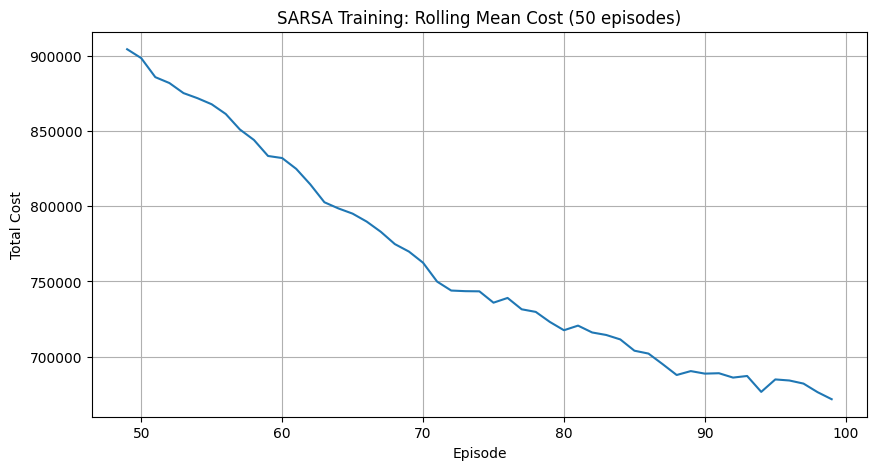

In [22]:
# @title Visualize SARSA convergence
plt.figure(figsize=(10, 5))
plt.plot(pd.Series(sarsa_h_costs).rolling(window=50).mean())
plt.title('SARSA Training: Rolling Mean Cost (50 episodes)')
plt.xlabel('Episode')
plt.ylabel('Total Cost')
plt.grid(True)
plt.show()

In [23]:
# @title Saving Tabular SARSA model
sarsa_path = 'sarsa_table_trained.npy'
model_save_path = np.save(sarsa_path, trained_sarsa_h_q_table)
print(f"Trained Tabular SARSA model saved to {sarsa_path}")

Trained Tabular SARSA model saved to sarsa_table_trained.npy


In [24]:
# @title Inference using saved Tabular SARSA model

N = 3 # Number of Products
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = N
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES) # 11 (0 to 100 in steps of 10)
NUM_TOTAL_ACTIONS = NUM_CHOICES_PER_PRODUCT ** NUM_PRODUCTS # 11^3 = 1331
NUM_DISCRETE_STATES = 27 * 8 * 3  # From discrete_state_aggregation (Inventory * Pipeline * DayPhase)

def discrete_state_aggregation(obs: dict) -> int:
    'Aggregates continuous state variables into a single discrete state index.'
    # Inventory Bins (per product): Low ([0, 30)), Medium ([30, 80)), High (>= 80).
    inventory_bins = []
    for i in range(N):
        if obs['inventory'][i] < 30:
            inventory_bins.append(0) # Low
        elif obs['inventory'][i] < 80:
            inventory_bins.append(1) # Medium
        else:
            inventory_bins.append(2) # High
    inventory_state = inventory_bins[0] * 9 + inventory_bins[1] * 3 + inventory_bins[2] * 1

    # Total Pipeline Sum Bins (per product): Low ([0, 30)), High (>= 30).
    pipeline_bins = []
    for i in range(N):
        total_pipeline_sum = obs['arrival_pipeline'][i].sum()
        if total_pipeline_sum < 30:
            pipeline_bins.append(0) # Low
        else:
            pipeline_bins.append(1) # High
    pipeline_state = pipeline_bins[0] * 4 + pipeline_bins[1] * 2 + pipeline_bins[2] * 1

    # Episode Phase: Early (t <= 15), Mid (15 < t <= 35), Late (t > 35).
    day = obs['day'][0]
    if day <= 15:
        day_state = 0 # Early
    elif day <= 35:
        day_state = 1 # Mid
    else:
        day_state = 2 # Late

    discrete_state = inventory_state * (8 * 3) + pipeline_state * 3 + day_state
    return discrete_state

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    'Converts a single integer action index to a MultiDiscrete action tuple.'
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

# Set initial table to zeroes.
initial_sarsa_q_table = np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS))

model_path = Path('./sarsa_table_trained.npy')

if model_path.exists():
    try:
        sarsa_q_table = np.load(model_path)
        print(f'SARSA Q-table loaded successfully from {model_path}')
    except Exception as e:
        print(f'Error loading SARSA Q-table from {model_path}: {e}')
        print('SARSA Q-table initialized with zeros instead.')
        sarsa_q_table = initial_sarsa_q_table
else:
    print(f'Warning: Model file not found at {model_path}. SARSA Q-table initialized with zeros.')
    print('Please ensure your trained sarsa_table_trained.npy is saved in the correct location.')
    sarsa_q_table = initial_sarsa_q_table


# Run policy in real time.
def run_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained Tabular SARSA policy.'

    # Get discrete state from observation
    state = discrete_state_aggregation(observation)

    # Choose action with the highest Q-value (exploitation only)
    action_idx = np.argmax(sarsa_q_table[state, :])

    # Convert single action index to MultiDiscrete action tuple
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)

    # Convert MultiDiscrete indices to actual quantities
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Test execution of run_policy
if __name__ == '__main__':
    print('\n--- Testing run_policy function for SARSA ---')
    dummy_observation = {
        'inventory': np.array([50, 60, 70], dtype=np.int32),
        'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
        'demand_history': np.zeros((7, 3), dtype=np.int32),
        'day': np.array([10], dtype=np.int32),
        'capacity_utilisation': np.array([0.5], dtype=np.float32)
    }
    recommended_quantities = run_policy(dummy_observation)
    print(f'Recommended quantities for dummy observation: {recommended_quantities}')

SARSA Q-table loaded successfully from sarsa_table_trained.npy

--- Testing run_policy function for SARSA ---
Recommended quantities for dummy observation: [0, 0, 0]


# Deep Q-Network (DQN)

**Loss Function:** $$L(\theta) = \mathbb{E}_{(s, a, r, s') \sim \mathcal{D}} \left[ \left( r + \gamma \max_{a'} Q(s', a'; \theta^-) - Q(s, a; \theta) \right)^2 \right]$$ where $\theta^-$ denotes parameters of the target network updated every $C$ steps.

In [25]:
STATE_DIM = 38
ACTION_DIM = NUM_TOTAL_ACTIONS

# Updated DQN Hyperparameters for cost reduction
DQN_LEARNING_RATE = 0.0001
BATCH_SIZE = 128
BUFFER_SIZE = 100000
MIN_WARMUP_SIZE = 1000
TARGET_UPDATE_FREQ = 500
TAU = 0.005 # For potential soft update
GAMMA = 0.98

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)
    def __len__(self):
        return len(self.buffer)

class DQNNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )
    def forward(self, x):
        return self.net(x)

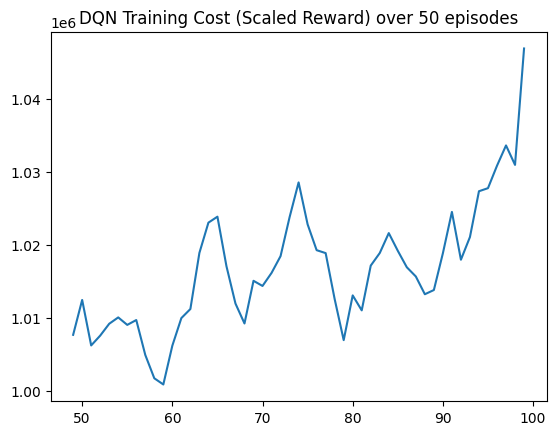

In [26]:
def train_dqn(env, num_episodes, lr, gamma, epsilon, epsilon_decay, min_epsilon, batch_size, buffer_size, target_update_freq):
    policy_net = DQNNetwork(STATE_DIM, ACTION_DIM)
    target_net = DQNNetwork(STATE_DIM, ACTION_DIM)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    criterion = nn.MSELoss()
    memory = ReplayBuffer(buffer_size)

    episode_costs = []
    curr_epsilon = epsilon
    observation, _ = env.reset(seed=SEED)

    for episode in range(num_episodes):
      # Use dynamic seeding for training to improve generalization
        if episode > 0:
          observation, _ = env.reset()
        state = continuous_state_normalization(observation)
        total_cost = 0.0

        for t in range(T):
            state_t = torch.FloatTensor(state).unsqueeze(0)
            if random.random() < curr_epsilon:
                action_idx = random.randint(0, ACTION_DIM - 1)
            else:
                with torch.no_grad():
                    action_idx = policy_net(state_t).argmax(1).item()

            # Map action index to quantities
            multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
            quantities = action_index_to_quantity(multi_discrete_action)
            env_action = env.quantities_to_action_indices(quantities)

            # Step in the environment
            next_obs, env_reward, terminated, truncated, info = env.step(env_action)
            next_state = continuous_state_normalization(next_obs)

            # Apply custom reward calculation for scaled learning signal
            cost_data = calculate_costs_and_reward(
                inventory=next_obs['inventory'],
                inventory_available=observation['inventory'],
                demand=info['demand'],
                orders=np.array(quantities),
                discarded_units=info['discarded_units']
            )
            reward = cost_data['base_reward']

            total_cost += info['costs']['daily_total']
            done = terminated or truncated
            memory.push(state, action_idx, reward, next_state, done)

            state = next_state
            obs = next_obs # Update observation for the next reward calculation step

            if len(memory) > MIN_WARMUP_SIZE:
                transitions = memory.sample(batch_size)
                b_s, b_a, b_r, b_ns, b_d = zip(*transitions)

                b_s = torch.FloatTensor(np.array(b_s))
                b_a = torch.LongTensor(b_a).unsqueeze(1)
                b_r = torch.FloatTensor(b_r).unsqueeze(1)
                b_ns = torch.FloatTensor(np.array(b_ns))
                b_d = torch.FloatTensor(b_d).unsqueeze(1)

                q_values = policy_net(b_s).gather(1, b_a)
                with torch.no_grad():
                    max_next_q = target_net(b_ns).max(1)[0].unsqueeze(1)
                    targets = b_r + (gamma * max_next_q * (1 - b_d))

                loss = criterion(q_values, targets)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            if done: break

        if (episode + 1) % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

        curr_epsilon = max(min_epsilon, curr_epsilon * epsilon_decay)
        episode_costs.append(total_cost)
        if (episode + 1) % 500 == 0:
            print(f"Ep {episode+1}/{num_episodes}: Avg Cost={np.mean(episode_costs[-500:]):.1f}, Eps={curr_epsilon:.3f}")

    return policy_net, episode_costs

training_env_dqn = IndustrialInventoryEnv(student_config=student_config, scenario_mode='random', domain_randomization=True)
trained_dqn_policy_net, dqn_training_costs = train_dqn(
    env=training_env_dqn,
    num_episodes=TRAINING_EPISODES,
    lr=DQN_LEARNING_RATE,
    gamma=GAMMA,
    epsilon=1.0,
    epsilon_decay=0.9995,
    min_epsilon=0.05,
    batch_size=BATCH_SIZE,
    buffer_size=BUFFER_SIZE,
    target_update_freq=TARGET_UPDATE_FREQ
)

plt.plot(pd.Series(dqn_training_costs).rolling(50).mean())
plt.title('DQN Training Cost (Scaled Reward) over 50 episodes')
plt.show()


In [27]:
def dqn_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained DQN policy.'
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    trained_dqn_policy_net.eval() # Set the model to evaluation mode.

    with torch.no_grad(): # Disable gradient calculations for efficiency
        action_idx = trained_dqn_policy_net(state_tensor).argmax(1).item()

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Evaluate the DQN policy
print('Evaluating DQN...')
dqn_results = evaluate_policy(dqn_policy, student_config)
display(dqn_results)

Evaluating DQN...


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,1372177.125,79946.031782,0.92,0.906


In [28]:
# @title Save DQN model

model_save_path = 'dqn_model.pth'
torch.save(trained_dqn_policy_net.state_dict(), model_save_path)
print(f"Trained DQN model saved to {model_save_path}")

Trained DQN model saved to dqn_model.pth


In [29]:
# @title Inference using saved DQN model

STATE_DIM = 38  # inv(3) + pipeline(12) + demand_hist(21) + day(1) + capacity(1)
ACTION_DIM = 1331 # 11^3 (11 choices per product, 3 products)
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = 3
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES)

# --- Helper Functions (copied from notebook for self-containment) ---
def continuous_state_normalization(obs: dict) -> np.ndarray:
    'Normalizes and flattens the raw observation dictionary into a continuous vector.'
    inventory_norm = obs['inventory'].astype(float) / 500.0
    pipeline_norm = obs['arrival_pipeline'].flatten().astype(float) / 200.0
    demand_history_norm = obs['demand_history'].flatten().astype(float) / 100.0
    day_norm = obs['day'].astype(float) / 50.0
    capacity_utilisation_norm = obs['capacity_utilisation'].astype(float)
    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    'Converts a single integer action index to a MultiDiscrete action tuple.'
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

# DQN Network Definition
class DQNNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# Global Model Instance and Loading
dqn_policy_model = DQNNetwork(STATE_DIM, ACTION_DIM)
# Load trained model
model_path = Path('./dqn_model.pth')

if model_path.exists():
    try:
        dqn_policy_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        print(f'DQN model loaded successfully from {model_path}')
    except Exception as e:
        print(f'Error loading model from {model_path}: {e}')
        print('DQN model initialized with random weights instead.')
else:
    print(f'Warning: Model file not found at {model_path}. DQN model initialized with random weights.')
    print('Please ensure your trained dqn_model.pth is saved in the correct location.')

dqn_policy_model.eval() # Set the model to evaluation mode.

# Main submission for leaderboard
def run_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained DQN policy.'

    # Preprocess the observation
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    # Perform inference
    with torch.no_grad(): # Disable gradient calculations for efficiency
        action_idx = dqn_policy_model(state_tensor).argmax(1).item()

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# --- Example Usage (This block is for testing and would NOT be in the final policy.py submission) ---
if __name__ == '__main__':
    print('\n--- Testing run_policy function for DQN ---')
    dummy_observation = {
        'inventory': np.array([50, 60, 70], dtype=np.int32),
        'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
        'demand_history': np.zeros((7, 3), dtype=np.int32),
        'day': np.array([10], dtype=np.int32),
        'capacity_utilisation': np.array([0.5], dtype=np.float32)
    }
    recommended_quantities = run_policy(dummy_observation)
    print(f'Recommended quantities for dummy observation: {recommended_quantities}')

DQN model loaded successfully from dqn_model.pth

--- Testing run_policy function for DQN ---
Recommended quantities for dummy observation: [30, 40, 100]


# Double DQN

Double DQN addresses the overestimation bias of Q-values inherent in standard DQN by decoupling the action selection from the action evaluation in the target Q-value calculation. Instead of using the target network to both select and evaluate the next action, Double DQN uses the **policy network** to select the best action in the next state and the **target network** to evaluate the Q-value of that selected action.

The loss function for Double DQN is a modification of the standard DQN loss:

$$L(\theta) = \mathbb{E}_{(s, a, r, s') \sim \mathcal{D}} \left[ \left( r + \gamma Q(s', \arg\max_{a'} Q(s', a'; \theta); \theta^-) - Q(s, a; \theta) \right)^2 \right]$$

Where:
*   $Q(s, a; \theta)$ is the Q-value from the **policy network** for the current state-action pair.
*   $Q(s', \arg\max_{a'} Q(s', a'; \theta); \theta^-)$ is the target Q-value:
    *   $\arg\max_{a'} Q(s', a'; \theta)$ uses the **policy network** (with parameters $\theta$) to select the best action $a'$ in the next state $s'$.
    *   $Q(s', \text{selected } a'; \theta^-)$ then uses the **target network** (with parameters $\theta^-$) to evaluate the Q-value of that selected action.

$\\theta^-$ denotes parameters of the target network updated every $C$ steps, similar to standard DQN.

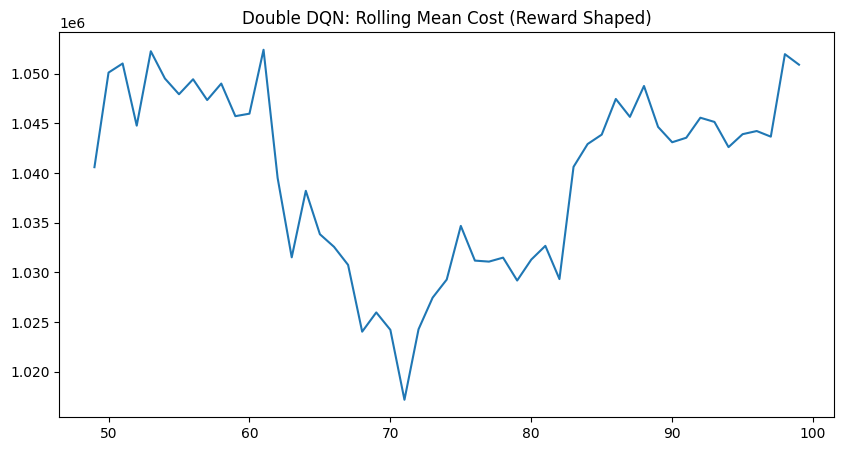

In [30]:
# Training function for Double DQN
def train_double_dqn(
    env: IndustrialInventoryEnv,
    num_episodes: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    epsilon_decay: float,
    min_epsilon: float,
    batch_size: int,
    buffer_size: int,
    target_update_freq: int,
) -> tuple[nn.Module, list[float]]:
    'Train a Double DQN agent with reward shaping.'

    policy_net = DQNNetwork(STATE_DIM, ACTION_DIM)
    target_net = DQNNetwork(STATE_DIM, ACTION_DIM)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=alpha)
    criterion = nn.MSELoss()
    replay_buffer = ReplayBuffer(buffer_size)

    episode_costs = []
    current_epsilon = epsilon
    observation, _ = env.reset(seed=SEED)

    for episode in range(num_episodes):
        # Use dynamic seeding for training to improve generalization
        if episode > 0:
          observation, _ = env.reset()
        state = continuous_state_normalization(observation)

        terminated = False
        truncated = False
        episode_total_cost = 0.0

        while not terminated and not truncated:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)

            if np.random.rand() < current_epsilon:
                action_idx = np.random.randint(0, ACTION_DIM)
            else:
                with torch.no_grad():
                    action_idx = policy_net(state_tensor).argmax(1).item()

            multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
            quantities = action_index_to_quantity(multi_discrete_action)
            env_action_indices = env.quantities_to_action_indices(quantities)

            next_observation, _, terminated, truncated, info = env.step(env_action_indices)
            next_state = continuous_state_normalization(next_observation)

            # Apply custom reward shaping
            cost_data = calculate_costs_and_reward(
                inventory=next_observation['inventory'],
                inventory_available=observation['inventory'],
                demand=info['demand'],
                orders=np.array(quantities),
                discarded_units=info['discarded_units']
            )
            reward = cost_data['base_reward']

            episode_total_cost += info['costs']['daily_total']
            done = terminated or truncated
            replay_buffer.push(state, action_idx, reward, next_state, done)

            state = next_state
            observation = next_observation

            if len(replay_buffer) > batch_size:
                experiences = replay_buffer.sample(batch_size)
                states, actions, rewards, next_states, dones = zip(*experiences)

                states_t = torch.FloatTensor(np.array(states))
                actions_t = torch.LongTensor(actions).unsqueeze(1)
                rewards_t = torch.FloatTensor(rewards).unsqueeze(1)
                next_states_t = torch.FloatTensor(np.array(next_states))
                dones_t = torch.FloatTensor(dones).unsqueeze(1)

                q_values = policy_net(states_t).gather(1, actions_t)

                with torch.no_grad():
                    next_action_selection = policy_net(next_states_t).argmax(1).unsqueeze(1)
                    next_q_values = target_net(next_states_t).gather(1, next_action_selection)
                    target_q_values = rewards_t + (gamma * next_q_values * (1 - dones_t))

                loss = criterion(q_values, target_q_values)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        episode_costs.append(episode_total_cost)
        if (episode + 1) % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

        current_epsilon = max(min_epsilon, current_epsilon * epsilon_decay)

        if (episode + 1) % 500 == 0:
            print(f'Episode {episode + 1}/{num_episodes}, Cost: {episode_total_cost:.2f}, Epsilon: {current_epsilon:.4f}')

    return policy_net, episode_costs

# Initialize and Train
training_env_double_dqn = IndustrialInventoryEnv(student_config=student_config, scenario_mode='random', domain_randomization=True)
trained_double_dqn_policy_net, double_dqn_training_episode_costs = train_double_dqn(
    env=training_env_double_dqn,
    num_episodes=TRAINING_EPISODES,
    alpha=0.0001,
    gamma=GAMMA,
    epsilon=1.0,
    epsilon_decay=0.9995,
    min_epsilon=0.05,
    batch_size=BATCH_SIZE,
    buffer_size=BUFFER_SIZE,
    target_update_freq=TARGET_UPDATE_FREQ,
)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(pd.Series(double_dqn_training_episode_costs).rolling(50).mean())
plt.title('Double DQN: Rolling Mean Cost (Reward Shaped)')
plt.show()

In [55]:
def double_dqn_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained Double DQN policy.'
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    trained_dqn_policy_net.eval() # Set the model to evaluation mode.

    with torch.no_grad(): # Disable gradient calculations for efficiency
        action_idx = trained_double_dqn_policy_net(state_tensor).argmax(1).item()

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Evaluate the Double DQN policy
print('Evaluating Double DQN...')
double_dqn_results = evaluate_policy(double_dqn_policy, student_config)
display(double_dqn_results)

Evaluating Double DQN...


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,1925388.125,56068.17406,0.951,0.876


In [32]:
"# @title Save Double DQN model

model_save_path = 'double_dqn_model.pth'
torch.save(trained_dqn_policy_net.state_dict(), model_save_path)
print(f"Trained Double DQN model saved to {model_save_path}")

Trained Double DQN model saved to double_dqn_model.pth


In [33]:
# @title Inference using saved Double DQN model

STATE_DIM = 38  # inv(3) + pipeline(12) + demand_hist(21) + day(1) + capacity(1)
ACTION_DIM = 1331 # 11^3 (11 choices per product, 3 products)
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = 3
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES)

def continuous_state_normalization(obs: dict) -> np.ndarray:
    'Normalizes and flattens the raw observation dictionary into a continuous vector.'
    inventory_norm = obs['inventory'].astype(float) / 500.0
    pipeline_norm = obs['arrival_pipeline'].flatten().astype(float) / 200.0
    demand_history_norm = obs['demand_history'].flatten().astype(float) / 100.0
    day_norm = obs['day'].astype(float) / 50.0
    capacity_utilisation_norm = obs['capacity_utilisation'].astype(float)
    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    'Converts a single integer action index to a MultiDiscrete action tuple.'
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

# DQN Network Definition
class DQNNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, x):
        return self.net(x)

dqn_policy_model = DQNNetwork(STATE_DIM, ACTION_DIM)

# Save model to reuse.
model_path = Path('./double_dqn_model.pth')
if model_path.exists():
    try:
        dqn_policy_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        print(f'Double DQN model loaded successfully from {model_path}')
    except Exception as e:
        print(f'Error loading model from {model_path}: {e}')
        print('Double DQN model initialized with random weights instead.')
else:
    print(f'Warning: Model file not found at {model_path}. Double DQN model initialized with random weights.')
    print('Please ensure your trained double_dqn_model.pth is saved in the correct location.')

dqn_policy_model.eval() # Set the model to evaluation mode.

# Main function for leaderboard.
def run_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained Double DQN policy.'

    # Preprocess the observation
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    # Perform inference
    with torch.no_grad(): # Disable gradient calculations for efficiency
        action_idx = dqn_policy_model(state_tensor).argmax(1).item()

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Run inference on run_policy
if __name__ == '__main__':
    print('\n--- Testing run_policy function for Double DQN ---')
    dummy_observation = {
        'inventory': np.array([50, 60, 70], dtype=np.int32),
        'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
        'demand_history': np.zeros((7, 3), dtype=np.int32),
        'day': np.array([10], dtype=np.int32),
        'capacity_utilisation': np.array([0.5], dtype=np.float32)
    }
    recommended_quantities = run_policy(dummy_observation)
    print(f'Recommended quantities for dummy observation: {recommended_quantities}')

Double DQN model loaded successfully from double_dqn_model.pth

--- Testing run_policy function for Double DQN ---
Recommended quantities for dummy observation: [30, 40, 100]


# PPO

In [34]:
# PPO Tuning: Lower Clip and higher entropy to prevent cost spikes
PPO_LEARNING_RATE = 2e-5
PPO_GAMMA = 0.98
PPO_GAE_LAMBDA = 0.95
PPO_CLIP_EPSILON = 0.1
PPO_EPOCHS = 15
PPO_BATCH_SIZE = 128
PPO_STEPS_PER_EPISODE = T
PPO_ENTROPY_COEFF = 0.02

/tmp/ipykernel_2250/890030188.py:112: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  old_log_probs_t = torch.tensor(log_probs)


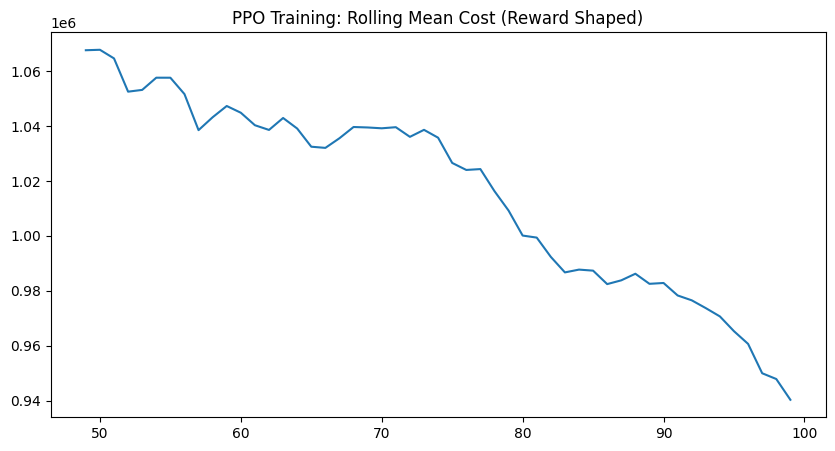

In [35]:
import torch.nn as nn

# ActorCritic structure
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.shared_net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU()
        )

        self.actor_net = nn.Sequential(
            nn.Linear(256, action_dim),
            nn.Softmax(dim=-1)
        )

        self.critic_net = nn.Sequential(
            nn.Linear(256, 1)
        )

    def forward(self, x):
        shared_features = self.shared_net(x)
        action_probs = self.actor_net(shared_features)
        state_values = self.critic_net(shared_features)
        return action_probs, state_values

# @title Train the PPO agent

def train_ppo_shaped(
    env: IndustrialInventoryEnv,
    num_episodes: int,
    ppo_learning_rate: float,
    ppo_gamma: float,
    ppo_gae_lambda: float,
    ppo_clip_epsilon: float,
    ppo_epochs: int,
    ppo_batch_size: int,
    ppo_steps_per_episode: int,
    ppo_entropy_coeff: float,
) -> tuple[nn.Module, list[float]]:
    policy_net = ActorCritic(STATE_DIM, ACTION_DIM)
    optimizer = optim.Adam(policy_net.parameters(), lr=ppo_learning_rate)
    episode_costs = []
    observation, _ = env.reset(seed=SEED)

    for episode in range(num_episodes):
      # Use dynamic seeding for training to improve generalization
        if episode > 0:
          observation, _ = env.reset()

        state = continuous_state_normalization(observation)
        states, actions, log_probs, rewards, values, masks = [], [], [], [], [], []
        episode_total_cost = 0.0

        for _ in range(ppo_steps_per_episode):
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            action_probs, value = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action = dist.sample()

            multi_discrete_action = map_action_index_to_multi_discrete(action.item())
            quantities = action_index_to_quantity(multi_discrete_action)
            env_action = env.quantities_to_action_indices(quantities)

            next_observation, _, terminated, truncated, info = env.step(env_action)
            next_state = continuous_state_normalization(next_observation)

            # Apply reward shaping
            cost_data = calculate_costs_and_reward(
                inventory=next_observation['inventory'],
                inventory_available=observation['inventory'],
                demand=info['demand'],
                orders=np.array(quantities),
                discarded_units=info['discarded_units']
            )
            reward = cost_data['base_reward']

            episode_total_cost += info['costs']['daily_total']
            done = terminated or truncated

            states.append(state)
            actions.append(action)
            log_probs.append(dist.log_prob(action))
            rewards.append(reward)
            values.append(value)
            masks.append(1 - done)

            state = next_state
            observation = next_observation
            if done: break

        episode_costs.append(episode_total_cost)

        # PPO Update Logic
        with torch.no_grad():
            _, last_value = policy_net(torch.FloatTensor(state).unsqueeze(0))
            returns = []
            gae = 0
            for i in reversed(range(len(rewards))):
                delta = rewards[i] + ppo_gamma * last_value * masks[i] - values[i]
                gae = delta + ppo_gamma * ppo_gae_lambda * masks[i] * gae
                last_value = values[i]
                returns.insert(0, gae + values[i])
            returns = torch.tensor(returns)
            advantages = returns - torch.tensor(values)

        states_t = torch.FloatTensor(np.array(states))
        actions_t = torch.tensor(actions)
        old_log_probs_t = torch.tensor(log_probs)
        returns_t = returns
        advantages_t = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        for _ in range(ppo_epochs):
            action_probs, values_pred = policy_net(states_t)
            dist = Categorical(action_probs)
            new_log_probs = dist.log_prob(actions_t)
            entropy = dist.entropy().mean()

            ratio = (new_log_probs - old_log_probs_t).exp()
            surr1 = ratio * advantages_t
            surr2 = torch.clamp(ratio, 1.0 - ppo_clip_epsilon, 1.0 + ppo_clip_epsilon) * advantages_t

            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = (returns_t - values_pred.squeeze()).pow(2).mean()
            loss = actor_loss + 0.5 * critic_loss - ppo_entropy_coeff * entropy

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if (episode + 1) % 500 == 0:
            print(f'Episode {episode+1}, Cost: {episode_total_cost:.1f}')

    return policy_net, episode_costs

training_env_ppo = IndustrialInventoryEnv(student_config=student_config, scenario_mode='random', domain_randomization=True)

trained_ppo_policy_net, ppo_training_episode_costs = train_ppo_shaped(
    env=training_env_ppo,
    num_episodes=TRAINING_EPISODES,
    ppo_learning_rate=PPO_LEARNING_RATE,
    ppo_gamma=PPO_GAMMA,
    ppo_gae_lambda=PPO_GAE_LAMBDA,
    ppo_clip_epsilon=PPO_CLIP_EPSILON,
    ppo_epochs=PPO_EPOCHS,
    ppo_batch_size=PPO_BATCH_SIZE,
    ppo_steps_per_episode=PPO_STEPS_PER_EPISODE,
    ppo_entropy_coeff=PPO_ENTROPY_COEFF
)

plt.figure(figsize=(10, 5))
plt.plot(pd.Series(ppo_training_episode_costs).rolling(50).mean())
plt.title('PPO Training: Rolling Mean Cost (Reward Shaped)')
plt.show()

In [36]:
def ppo_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained PPO policy.'
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    trained_ppo_policy_net.eval() # Set the model to evaluation mode.

    with torch.no_grad(): # Disable gradient calculations for efficiency
        action_probs, _ = trained_ppo_policy_net(state_tensor)
        dist = Categorical(action_probs)
        action_idx = dist.sample().item()

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Evaluate the PPO policy
print('Evaluating PPO...')
ppo_results = evaluate_policy(ppo_policy, student_config)
display(ppo_results)

Evaluating PPO...


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,771621.375,117384.673279,0.277,0.672


In [37]:
# @title Save the PPO model
model_save_path = 'ppo_model.pth'
torch.save(trained_ppo_policy_net.state_dict(), model_save_path)
print(f'Trained PPO model saved to {model_save_path}')

Trained PPO model saved to ppo_model.pth


In [38]:
# @title Inference by reading from PPO saved model

STATE_DIM = 38  # inv(3) + pipeline(12) + demand_hist(21) + day(1) + capacity(1)
ACTION_DIM = 1331 # 11^3 (11 choices per product, 3 products)
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = N # 3
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES)

def continuous_state_normalization(obs: dict) -> np.ndarray:
    'Normalizes and flattens the raw observation dictionary into a continuous vector.'
    inventory_norm = obs['inventory'].astype(float) / 500.0
    pipeline_norm = obs['arrival_pipeline'].flatten().astype(float) / 200.0
    demand_history_norm = obs['demand_history'].flatten().astype(float) / 100.0
    day_norm = obs['day'].astype(float) / 50.0
    capacity_utilisation_norm = obs['capacity_utilisation'].astype(float)
    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    'Converts a single integer action index to a MultiDiscrete action tuple.'
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

# ActorCritic structure
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.shared_net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU()
        )

        self.actor_net = nn.Sequential(
            nn.Linear(256, action_dim),
            nn.Softmax(dim=-1)
        )

        self.critic_net = nn.Sequential(
            nn.Linear(256, 1)
        )

    def forward(self, x):
        shared_features = self.shared_net(x)
        action_probs = self.actor_net(shared_features)
        state_values = self.critic_net(shared_features)
        return action_probs, state_values

ppo_policy_model = ActorCritic(STATE_DIM, ACTION_DIM)
model_path = Path('./ppo_model.pth') # Assuming model is saved in the same directory

if model_path.exists():
    try:
        ppo_policy_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        print(f'PPO model loaded successfully from {model_path}')
    except Exception as e:
        print(f'Error loading model from {model_path}: {e}')
        print('PPO model initialized with random weights instead.')
else:
    print(f'Warning: Model file not found at {model_path}. PPO model initialized with random weights.')
    print('Please ensure your trained ppo_model.pth is saved in the correct location.')

ppo_policy_model.eval() # Set the model to evaluation mode.

# run_policy for evaluation
def run_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained PPO policy.'

    # Preprocess the observation
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    # Perform inference
    with torch.no_grad(): # Disable gradient calculations for efficiency
        action_probs, _ = ppo_policy_model(state_tensor)
        dist = Categorical(action_probs)
        action_idx = dist.sample().item()

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Run inference on run_policy
if __name__ == '__main__':
    print('\n--- Testing run_policy function for PPO ---')
    dummy_observation = {
        'inventory': np.array([50, 60, 70], dtype=np.int32),
        'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
        'demand_history': np.zeros((7, 3), dtype=np.int32),
        'day': np.array([10], dtype=np.int32),
        'capacity_utilisation': np.array([0.5], dtype=np.float32)
    }
    recommended_quantities = run_policy(dummy_observation)
    print(f'Recommended quantities for dummy observation: {recommended_quantities}')

PPO model loaded successfully from ppo_model.pth

--- Testing run_policy function for PPO ---
Recommended quantities for dummy observation: [40, 0, 10]


# Actor 3 Critic (A3C) with 8 workers

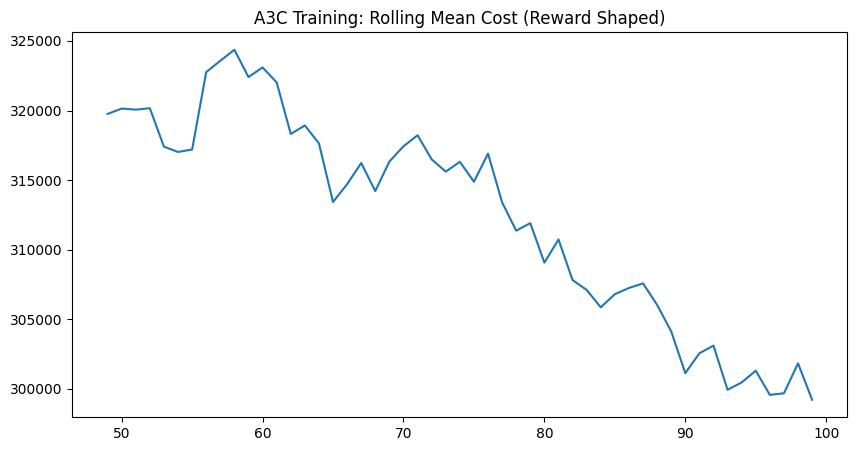

In [39]:
# Hyperparameters in A3C
A3C_LEARNING_RATE = 0.0003
A3C_GAMMA = 0.99
A3C_ENTROPY_COEFF = 0.01
A3C_N_STEPS = 20
A3C_GAE_LAMBDA = 0.95

def compute_gae(rewards, values, dones, gamma, lam):
    advantages = torch.zeros_like(rewards)
    last_gae = 0
    for t in reversed(range(len(rewards))):
        mask = 1.0 - dones[t]
        delta = rewards[t] + gamma * values[t+1] * mask - values[t]
        last_gae = delta + gamma * lam * mask * last_gae
        advantages[t] = last_gae
    return advantages

# Actor-Critic Network for A3C
class A3CActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.shared_net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU()
        )
        self.actor_net = nn.Sequential(
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1)
        )
        self.critic_net = nn.Sequential(
            nn.Linear(128, 1)
        )

    def forward(self, x):
        shared_features = self.shared_net(x)
        action_probs = self.actor_net(shared_features)
        state_values = self.critic_net(shared_features)
        return action_probs, state_values

def train_a3c(
    env: IndustrialInventoryEnv,
    num_episodes: int,
    a3c_learning_rate: float,
    a3c_gamma: float,
    a3c_gae_lambda: float,
    a3c_entropy_coeff: float,
    a3c_n_steps: int,
) -> tuple[nn.Module, list[float]]:
    policy_net = A3CActorCritic(STATE_DIM, ACTION_DIM)
    optimizer = optim.Adam(policy_net.parameters(), lr=a3c_learning_rate)
    episode_costs = []
    observation, _ = env.reset(seed=SEED)

    for episode in range(num_episodes):
      # Use dynamic seeding for training to improve generalization
        if episode > 0:
          observation, _ = env.reset()
        state = continuous_state_normalization(observation)
        episode_total_cost = 0.0
        states_buffer, actions_buffer, rewards_buffer, values_buffer, log_probs_buffer, dones_buffer = [], [], [], [], [], []

        terminated, truncated = False, False
        step_count = 0

        while not terminated and not truncated and step_count < a3c_n_steps:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            action_probs, value = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action_idx = dist.sample()
            log_prob = dist.log_prob(action_idx)

            multi_discrete_action = map_action_index_to_multi_discrete(action_idx.item())
            quantities = action_index_to_quantity(multi_discrete_action)
            env_action_indices = env.quantities_to_action_indices(quantities)

            next_observation, _, terminated, truncated, info = env.step(env_action_indices)
            next_state = continuous_state_normalization(next_observation)

            # Apply reward shaping using the provided function
            cost_data = calculate_costs_and_reward(
                inventory=next_observation['inventory'],
                inventory_available=observation['inventory'],
                demand=info['demand'],
                orders=np.array(quantities),
                discarded_units=info['discarded_units']
            )
            reward = cost_data['base_reward']

            episode_total_cost += info['costs']['daily_total']

            states_buffer.append(state)
            actions_buffer.append(action_idx)
            rewards_buffer.append(reward)
            values_buffer.append(value.detach().squeeze().item())
            log_probs_buffer.append(log_prob)
            dones_buffer.append(terminated or truncated)

            state = next_state
            observation = next_observation
            step_count += 1
            if terminated or truncated: break

        episode_costs.append(episode_total_cost)

        R = 0
        if not (terminated or truncated):
            with torch.no_grad():
                _, last_state_value = policy_net(torch.FloatTensor(state).unsqueeze(0))
                R = last_state_value.squeeze().item()

        values_for_gae = values_buffer + [R]
        rewards_tensor = torch.FloatTensor(rewards_buffer).unsqueeze(1)
        values_tensor = torch.FloatTensor(values_for_gae).unsqueeze(1)
        dones_tensor = torch.FloatTensor(dones_buffer).unsqueeze(1)

        advantages = compute_gae(rewards_tensor, values_tensor, dones_tensor, a3c_gamma, a3c_gae_lambda)
        returns = advantages + torch.FloatTensor(values_buffer).unsqueeze(1)

        states_tensor = torch.FloatTensor(np.array(states_buffer))
        actions_tensor = torch.cat(actions_buffer).unsqueeze(1)

        new_action_probs, new_values = policy_net(states_tensor)
        new_dist = Categorical(new_action_probs)
        current_log_probs = new_dist.log_prob(actions_tensor.squeeze(1)).unsqueeze(1)

        actor_loss = -(current_log_probs * advantages.detach()).mean() - a3c_entropy_coeff * new_dist.entropy().mean()
        critic_loss = nn.MSELoss()(new_values, returns)
        loss = actor_loss + 0.5 * critic_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 0.5)
        optimizer.step()

        if (episode + 1) % 500 == 0:
            print(f'Episode {episode + 1}/{num_episodes}, Total Cost: {episode_total_cost:.2f}')

    return policy_net, episode_costs

def a3c_inference_policy(observation: dict, policy_net: nn.Module) -> list[int]:
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    policy_net.eval()
    with torch.no_grad():
        action_probs, _ = policy_net(state_tensor)
        action_idx = action_probs.argmax(1).item()
    return action_index_to_quantity(map_action_index_to_multi_discrete(action_idx))

training_env_a3c = IndustrialInventoryEnv(student_config=student_config, scenario_mode='random', domain_randomization=True)
trained_a3c_policy_net, a3c_training_episode_costs = train_a3c(
    env=training_env_a3c,
    num_episodes=TRAINING_EPISODES,
    a3c_learning_rate=A3C_LEARNING_RATE,
    a3c_gamma=A3C_GAMMA,
    a3c_gae_lambda=A3C_GAE_LAMBDA,
    a3c_entropy_coeff=A3C_ENTROPY_COEFF,
    a3c_n_steps=A3C_N_STEPS,
)

plt.figure(figsize=(10, 5))
plt.plot(pd.Series(a3c_training_episode_costs).rolling(50).mean())
plt.title('A3C Training: Rolling Mean Cost (Reward Shaped)')
plt.show()

In [40]:
def a3c_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained A3C policy.'
    # The a3c_inference_policy function is defined in a previous cell (3fYCuCTMrRDW)
    # It takes the observation and the trained network as input.
    return a3c_inference_policy(observation, trained_a3c_policy_net)

# Evaluate the A3C policy
print('Evaluating A3C...')
a3c_results = evaluate_policy(a3c_policy, student_config)
display(a3c_results)

Evaluating A3C...


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,493272.5,24763.583886,0.893,0.0


In [41]:
# @title Save A3C model

model_save_path = 'a3c_model.pth'
torch.save(trained_a3c_policy_net.state_dict(), model_save_path)
print(f'Trained A3C model saved to {model_save_path}')

Trained A3C model saved to a3c_model.pth


In [42]:
# @title Run inference on saved A3C model

ACTION_DIM = 1331 # 11^3 (11 choices per product, 3 products)
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = 3
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES)

def continuous_state_normalization(obs: dict) -> np.ndarray:
    'Normalizes and flattens the raw observation dictionary into a continuous vector.'
    inventory_norm = obs['inventory'].astype(float) / 500.0
    pipeline_norm = obs['arrival_pipeline'].flatten().astype(float) / 200.0
    demand_history_norm = obs['demand_history'].flatten().astype(float) / 100.0
    day_norm = obs['day'].astype(float) / 50.0
    capacity_utilisation_norm = obs['capacity_utilisation'].astype(float)
    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    'Converts a single integer action index to a MultiDiscrete action tuple.'
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

# A3C copied from the network.
class A3CActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        # Shared backbone: 38 -> 128
        self.shared_net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU()
        )

        # Actor head: 128 -> ACTION_DIM (1331) with Softmax for actions.
        self.actor_net = nn.Sequential(
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1) # Output probabilities for each action
        )

        # Critic head: 128 -> 1 for state value prediction
        self.critic_net = nn.Sequential(
            nn.Linear(128, 1) # Output state value
        )

    def forward(self, x):
        shared_features = self.shared_net(x)
        action_probs = self.actor_net(shared_features)
        state_values = self.critic_net(shared_features)
        return action_probs, state_values

a3c_policy_model = A3CActorCritic(STATE_DIM, ACTION_DIM)

# Load model from saved path.
model_path = Path('./a3c_model.pth')

if model_path.exists():
    try:
        # Load the model's state_dict. map_location='cpu' is good practice for deployment.
        a3c_policy_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        print(f'A3C model loaded successfully from {model_path}')
    except Exception as e:
        print(f'Error loading model from {model_path}: {e}')
        print('A3C model initialized with random weights instead.')
else:
    print(f'Warning: Model file not found at {model_path}. A3C model initialized with random weights.')
    print('Please ensure your trained a3c_model.pth is saved in the correct location.')

a3c_policy_model.eval() # Set the model to evaluation mode; no gradients needed during inference.

# run_policy for public leaderboard
def run_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained A3C policy.'

    # Preprocess the observation
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    # Perform inference
    with torch.no_grad(): # Disable gradient calculations for efficiency
        action_probs, _ = a3c_policy_model(state_tensor)
        dist = Categorical(action_probs)
        # For inference, typically sample stochastically, or use argmax for deterministic
        action_idx = dist.sample().item()

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Run in real time.
    print('\n--- Testing run_policy function for A3C ---')
    dummy_observation = {
        'inventory': np.array([50, 60, 70], dtype=np.int32),
        'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
        'demand_history': np.zeros((7, 3), dtype=np.int32),
        'day': np.array([10], dtype=np.int32),
        'capacity_utilisation': np.array([0.5], dtype=np.float32)
    }
    recommended_quantities = run_policy(dummy_observation)
    print(f'Recommended quantities for dummy observation: {recommended_quantities}')

A3C model loaded successfully from a3c_model.pth


# Reinforcement learning

Starting REINFORCE training with reward shaping...
Episode 100/100, Rolling Cost: 1040032.3


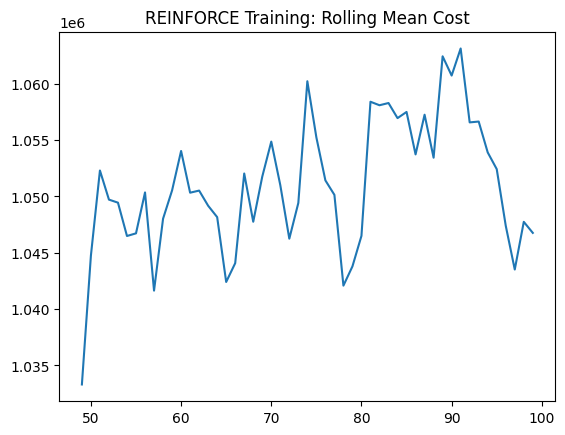

In [43]:
# @title Train reinforcement learning

REINFORCE_ACTOR_LR = 5e-4
REINFORCE_CRITIC_LR = 2e-3
REINFORCE_GAMMA = 0.85
REINFORCE_ENTROPY_COEFF = 0.005
REINFORCE_LR_DECAY = 0.999 # Exponential decay rate per episode
REINFORCE_MIN_LR = 1e-6 # Minimum learning rate

# Constants for the model to use
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES) # 0 to 100 in steps of 10
NUM_TOTAL_ACTIONS = NUM_CHOICES_PER_PRODUCT ** N # 11^3 = 1331
STATE_DIM = 38
NUM_PRODUCTS = N
ACTION_DIM = NUM_TOTAL_ACTIONS # Same as tabular: 11^3 = 1331
NUM_DISCRETE_STATES = 27 * 8 * NUM_PRODUCTS  # (Inventory * Pipeline * DayPhase)


def action_index_to_quantity(action_indices):
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    '''Converts a single integer action index to a MultiDiscrete action tuple.'''
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def continuous_state_normalization(obs: dict) -> np.ndarray:
    '''Normalizes and flattens the raw observation dictionary into a continuous vector.

    Args:
        obs: The raw observation dictionary from the environment.

    Returns:
        A numpy array representing the normalized continuous state vector.
    '''
    inventory_norm = obs['inventory'].astype(float) / 500.0
    pipeline_norm = obs['arrival_pipeline'].flatten().astype(float) / 200.0
    demand_history_norm = obs['demand_history'].flatten().astype(float) / 100.0
    day_norm = obs['day'].astype(float) / 50.0
    capacity_utilisation_norm = obs['capacity_utilisation'].astype(float)

    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)


class ReinforceActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.shared_net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.actor_net = nn.Sequential(
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )
        self.critic_net = nn.Sequential(
            nn.Linear(64, 1)
        )

    def forward(self, x):
        shared_features = self.shared_net(x)
        action_probs = self.actor_net(shared_features)
        state_values = self.critic_net(shared_features)
        return action_probs, state_values

def train_reinforce(
    env: IndustrialInventoryEnv,
    num_episodes: int,
    actor_lr: float,
    critic_lr: float,
    gamma: float,
    entropy_coeff: float,
    lr_decay: float,
    min_lr: float,
) -> tuple[nn.Module, list[float]]:
    'Trains a REINFORCE agent (with baseline) using reward shaping.'

    policy_net = ReinforceActorCritic(STATE_DIM, ACTION_DIM)
    actor_optimizer = optim.Adam(policy_net.actor_net.parameters(), lr=actor_lr)
    critic_optimizer = optim.Adam(policy_net.critic_net.parameters(), lr=critic_lr)

    actor_scheduler = optim.lr_scheduler.ExponentialLR(actor_optimizer, gamma=lr_decay)
    critic_scheduler = optim.lr_scheduler.ExponentialLR(critic_optimizer, gamma=lr_decay)

    episode_costs = []
    observation, _ = env.reset(seed=SEED)

    for episode in range(num_episodes):
        if episode > 0:
          observation, _ = env.reset()
        state = continuous_state_normalization(observation)

        episode_total_cost = 0.0
        states_buffer, actions_buffer, rewards_buffer, log_probs_buffer, values_buffer = [], [], [], [], []

        terminated = False
        truncated = False

        while not terminated and not truncated:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)

            action_probs, value = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action_idx = dist.sample()
            log_prob = dist.log_prob(action_idx)

            multi_discrete_action = map_action_index_to_multi_discrete(action_idx.item())
            quantities = action_index_to_quantity(multi_discrete_action)
            env_action_indices = env.quantities_to_action_indices(quantities)

            next_observation, _, terminated, truncated, info = env.step(env_action_indices)
            next_state = continuous_state_normalization(next_observation)

            # Apply reward shaping via calculate_costs_and_reward
            cost_data = calculate_costs_and_reward(
                inventory=next_observation['inventory'],
                inventory_available=observation['inventory'],
                demand=info['demand'],
                orders=np.array(quantities),
                discarded_units=info['discarded_units']
            )
            reward = cost_data['base_reward']

            episode_total_cost += info['costs']['daily_total']

            states_buffer.append(state)
            actions_buffer.append(action_idx)
            rewards_buffer.append(reward)
            log_probs_buffer.append(log_prob)
            values_buffer.append(value.squeeze().item())

            state = next_state
            observation = next_observation

        episode_costs.append(episode_total_cost)

        states_tensor = torch.FloatTensor(np.array(states_buffer))
        actions_tensor = torch.cat(actions_buffer).unsqueeze(1)
        rewards_tensor = torch.FloatTensor(rewards_buffer)
        log_probs_tensor = torch.cat(log_probs_buffer)
        values_tensor = torch.FloatTensor(values_buffer)

        returns = torch.zeros_like(rewards_tensor)
        running_add = 0
        for i in reversed(range(len(rewards_tensor))):
            running_add = rewards_tensor[i] + gamma * running_add
            returns[i] = running_add

        advantages = returns - values_tensor
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        action_probs, predicted_values = policy_net(states_tensor)
        dist = Categorical(action_probs)
        current_log_probs = dist.log_prob(actions_tensor.squeeze(1))
        entropy = dist.entropy().mean()

        actor_loss = -(current_log_probs * advantages.detach()).mean() - entropy_coeff * entropy
        critic_loss = nn.MSELoss()(predicted_values.squeeze(1), returns)

        actor_optimizer.zero_grad()
        actor_loss.backward(retain_graph=True)
        actor_optimizer.step()

        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()

        actor_scheduler.step()
        critic_scheduler.step()

        for param_group in actor_optimizer.param_groups:
            param_group['lr'] = max(min_lr, param_group['lr'])
        for param_group in critic_optimizer.param_groups:
            param_group['lr'] = max(min_lr, param_group['lr'])

        if (episode + 1) % 500 == 0 or episode == num_episodes - 1:
            print(f'Episode {episode + 1}/{num_episodes}, Rolling Cost: {np.mean(episode_costs[-100:]):.1f}')

    return policy_net, episode_costs

def reinforce_inference_policy(observation: dict, policy_net: nn.Module) -> list[int]:
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    policy_net.eval()
    with torch.no_grad():
        action_probs, _ = policy_net(state_tensor)
        action_idx = action_probs.argmax(1).item()
    return action_index_to_quantity(map_action_index_to_multi_discrete(action_idx))

print('Starting REINFORCE training with reward shaping...')
training_env_reinforce = IndustrialInventoryEnv(student_config=student_config, scenario_mode='random', domain_randomization=True)
trained_reinforce_policy_net, reinforce_training_episode_costs = train_reinforce(
    env=training_env_reinforce,
    num_episodes=TRAINING_EPISODES,
    actor_lr=REINFORCE_ACTOR_LR,
    critic_lr=REINFORCE_CRITIC_LR,
    gamma=REINFORCE_GAMMA,
    entropy_coeff=REINFORCE_ENTROPY_COEFF,
    lr_decay=REINFORCE_LR_DECAY,
    min_lr=REINFORCE_MIN_LR,
)

plt.plot(pd.Series(reinforce_training_episode_costs).rolling(50).mean())
plt.title('REINFORCE Training: Rolling Mean Cost')
plt.show()

In [44]:
def reinforce_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained Reinforcement Learning policy.'
    # It takes the observation and the trained network as input.
    return reinforce_inference_policy(observation, trained_reinforce_policy_net)

# Evaluate the Reinforcement Learning policy
print('Evaluating Reinforcement Learning...')
reinforce_results = evaluate_policy(reinforce_policy, student_config)
display(reinforce_results)

Evaluating Reinforcement Learning...


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,1494586.0,145214.026129,0.487,0.826


In [45]:
# @title Save Reinforce model
model_save_path = 'reinforce_model.pth'
torch.save(trained_reinforce_policy_net.state_dict(), model_save_path)
print(f'Trained Reinforce model saved to {model_save_path}')

Trained Reinforce model saved to reinforce_model.pth


In [46]:
# @title Run inference on saved model
REINFORCE_ACTOR_LR = 3e-4
REINFORCE_CRITIC_LR = 1e-3
REINFORCE_GAMMA = 0.95
REINFORCE_ENTROPY_COEFF = 0.001
REINFORCE_LR_DECAY = 0.999 # Exponential decay rate per episode
REINFORCE_MIN_LR = 1e-6 # Minimum learning rate
# Constants for the model to use
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES) # 0 to 100 in steps of 10
NUM_TOTAL_ACTIONS = NUM_CHOICES_PER_PRODUCT ** N # 11^3 = 1331
STATE_DIM = 38
NUM_PRODUCTS = N
ACTION_DIM = NUM_TOTAL_ACTIONS # Same as tabular: 11^3 = 1331
NUM_DISCRETE_STATES = 27 * 8 * NUM_PRODUCTS  # (Inventory * Pipeline * DayPhase)


def action_index_to_quantity(action_indices):
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    '''Converts a single integer action index to a MultiDiscrete action tuple.'''
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def continuous_state_normalization(obs: dict) -> np.ndarray:
    '''Normalizes and flattens the raw observation dictionary into a continuous vector.

    Args:
        obs: The raw observation dictionary from the environment.

    Returns:
        A numpy array representing the normalized continuous state vector.
    '''
    # I_t / 500.0
    inventory_norm = obs['inventory'].astype(float) / 500.0
    # vec(P_t) / 200.0
    pipeline_norm = obs['arrival_pipeline'].flatten().astype(float) / 200.0
    # vec(H_t) / 100.0
    demand_history_norm = obs['demand_history'].flatten().astype(float) / 100.0
    # t / 50.0
    day_norm = obs['day'].astype(float) / 50.0
    # U_t (already normalized)
    capacity_utilisation_norm = obs['capacity_utilisation'].astype(float)

    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)


# Actor-Critic Network for REINFORCE
class ReinforceActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        # Shared backbone: 38 -> 128 -> 64
        self.shared_net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Actor head: 64 -> ACTION_DIM (1331) with Softmax for probabilities
        self.actor_net = nn.Sequential(
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1) # Output probabilities for each action
        )

        # Critic head: 64 -> 1 for state value prediction
        self.critic_net = nn.Sequential(
            nn.Linear(64, 1) # Output state value
        )

    def forward(self, x):
        shared_features = self.shared_net(x)
        action_probs = self.actor_net(shared_features)
        state_values = self.critic_net(shared_features)
        return action_probs, state_values

reinforce_policy_model = ReinforceActorCritic(STATE_DIM, ACTION_DIM)

# Load model from saved path.
model_path = Path('./reinforce_model.pth')

if model_path.exists():
    try:
        # Load the model's state_dict. map_location='cpu' is good practice for deployment.
        reinforce_policy_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        print(f'reinforce model loaded successfully from {model_path}')
    except Exception as e:
        print(f'Error loading model from {model_path}: {e}')
        print('reinforce model initialized with random weights instead.')
else:
    print(f'Warning: Model file not found at {model_path}. reinforce model initialized with random weights.')
    print(f'Please ensure your trained {model_path} is saved in the correct location.')

reinforce_policy_model.eval() # Set the model to evaluation mode; no gradients needed during inference.


# run_policy for public leaderboard
def run_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained reinforce policy.'

    # Preprocess the observation
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    # Perform inference
    with torch.no_grad(): # Disable gradient calculations for efficiency
        action_probs, _ = reinforce_policy_model(state_tensor)
        dist = Categorical(action_probs)
        # For inference, typically sample stochastically, or use argmax for deterministic
        action_idx = dist.sample().item()

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

dummy_observation = {
    'inventory': np.array([50, 60, 70], dtype=np.int32),
    'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
    'demand_history': np.zeros((7, 3), dtype=np.int32),
    'day': np.array([10], dtype=np.int32),
    'capacity_utilisation': np.array([0.5], dtype=np.float32)
}
recommended_quantities = reinforce_inference_policy(dummy_observation, trained_reinforce_policy_net)
print(f'Recommended quantities for dummy observation: {recommended_quantities}')

reinforce model loaded successfully from reinforce_model.pth
Recommended quantities for dummy observation: [10, 40, 10]


# Neural Network based SARSA-Learning

Episode 100/100, Total Cost: 1080902.50, Epsilon: 0.8186
Neural Network based SARSA training finished.


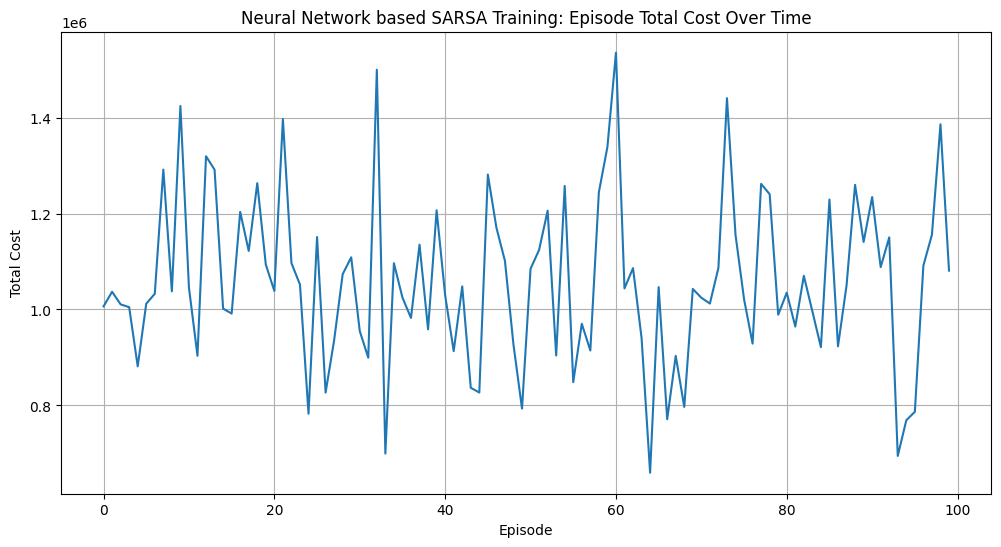

Neural Network based SARSA Evaluation Results:


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,1018061.5,147615.931937,0.648,0.761


In [47]:
STATE_DIM = 38
NUM_PRODUCTS = N
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES)
ACTION_DIM = NUM_CHOICES_PER_PRODUCT ** NUM_PRODUCTS # 11^3 = 1331

def continuous_state_normalization(obs: dict) -> np.ndarray:
    '''Normalizes and flattens the raw observation dictionary into a continuous vector.

    Args:
        obs: The raw observation dictionary from the environment.

    Returns:
        A numpy array representing the normalized continuous state vector.
    '''
    inventory_norm = obs['inventory'].astype(float) / 500.0
    pipeline_norm = obs['arrival_pipeline'].flatten().astype(float) / 200.0
    demand_history_norm = obs['demand_history'].flatten().astype(float) / 100.0
    day_norm = obs['day'].astype(float) / 50.0
    capacity_utilisation_norm = obs['capacity_utilisation'].astype(float)

    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    '''Converts a single integer action index to a MultiDiscrete action tuple.'''
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

# SARSA Hyperparameters
SARSA_LEARNING_RATE = 0.0005
BATCH_SIZE = 64
BUFFER_SIZE = 100000
TARGET_UPDATE_FREQ = 200

GAMMA = 0.99  # Discount factor
EPSILON = 1.0 # Exploration-exploitation trade-off
EPSILON_DECAY = 0.998 # Epsilon decay rate
MIN_EPSILON = 0.05 # Minimum epsilon

# Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    # For SARSA, we need to store the action taken in the *next* state (A_t+1)
    # when pushing the experience (S_t, A_t, R_t, S_{t+1}, A_{t+1})
    def push(self, state, action, reward, next_state, done, next_action_for_sarsa=None):
        self.buffer.append((state, action, reward, next_state, done, next_action_for_sarsa))

    def sample(self, batch_size):
        # Sample returns (state, action, reward, next_state, done, next_action_for_sarsa)
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

# SARSA Network (same architecture as DQNNetwork)
class SARSANetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# Training function for Neural Network based SARSA
def train_nn_sarsa(
    env: IndustrialInventoryEnv,
    num_episodes: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    epsilon_decay: float,
    min_epsilon: float,
    batch_size: int,
    buffer_size: int,
    target_update_freq: int,
) -> tuple[nn.Module, list[float]]:
    'Trains a Neural Network based SARSA agent on the Industrial Inventory environment.'

    policy_net = SARSANetwork(STATE_DIM, ACTION_DIM)
    target_net = SARSANetwork(STATE_DIM, ACTION_DIM)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval() # Set target network to evaluation mode

    optimizer = optim.Adam(policy_net.parameters(), lr=alpha)
    criterion = nn.MSELoss() # Loss function
    replay_buffer = ReplayBuffer(buffer_size)

    episode_costs = []
    current_epsilon = epsilon
    observation, _ = env.reset(seed=SEED)

    for episode in range(num_episodes):
      if episode > 0:
          observation, _ = env.reset()
      state = continuous_state_normalization(observation)
      state_tensor = torch.FloatTensor(state).unsqueeze(0) # Batch dimension

      # Choose initial action A_t using epsilon-greedy policy from policy_net
      if np.random.rand() < current_epsilon:
        action_t_idx = np.random.randint(0, ACTION_DIM)
      else:
        with torch.no_grad():
          action_t_idx = policy_net(state_tensor).argmax(1).item()

      terminated = False
      truncated = False
      episode_total_cost = 0.0

      for t in range(T): # Max 50 days per episode
          # Convert single action index to environment's MultiDiscrete indices
          multi_discrete_action_t = map_action_index_to_multi_discrete(action_t_idx)
          # Convert MultiDiscrete indices to actual quantities
          quantities_t = action_index_to_quantity(multi_discrete_action_t)
          # Convert quantities to environment's internal action indices for `env.step`
          env_action_indices_t = env.quantities_to_action_indices(quantities_t)

          # Take action A_t and observe next state S_{t+1} and reward R_t
          next_observation, reward, terminated, truncated, info = env.step(env_action_indices_t)
          next_state = continuous_state_normalization(next_observation)
          episode_total_cost += info['costs']['daily_total']

          # Choose next action A_{t+1} using epsilon-greedy policy from policy_net
          action_t_plus_1_idx = None
          if not (terminated or truncated): # Only determine next_action if not a terminal state
              next_state_tensor_for_action_selection = torch.FloatTensor(next_state).unsqueeze(0)
              if np.random.rand() < current_epsilon:
                  action_t_plus_1_idx = np.random.randint(0, ACTION_DIM)
              else:
                  with torch.no_grad():
                      action_t_plus_1_idx = policy_net(next_state_tensor_for_action_selection).argmax(1).item()

          # Store experience in replay buffer (including A_{t+1})
          done = terminated or truncated
          replay_buffer.push(state, action_t_idx, reward, next_state, done, action_t_plus_1_idx)

          state = next_state
          state_tensor = torch.FloatTensor(state).unsqueeze(0)
          action_t_idx = action_t_plus_1_idx # A_{t+1} becomes A_t for the next iteration

          if done:
              break

          # Train the network if enough samples in buffer
          if len(replay_buffer) > batch_size:
              experiences = replay_buffer.sample(batch_size)
              # Unpack all 6 components for SARSA
              states_batch, actions_batch, rewards_batch, next_states_batch, dones_batch, next_actions_batch = zip(*experiences)

              states_tensor_batch = torch.FloatTensor(np.array(states_batch))
              actions_tensor_batch = torch.LongTensor(actions_batch).unsqueeze(1)
              rewards_tensor_batch = torch.FloatTensor(rewards_batch).unsqueeze(1)
              next_states_tensor_batch = torch.FloatTensor(np.array(next_states_batch))
              dones_tensor_batch = torch.FloatTensor(dones_batch).unsqueeze(1)

              # Compute Q(s_t, a_t; theta)
              q_values = policy_net(states_tensor_batch).gather(1, actions_tensor_batch)

              # Compute target Q-values: r + gamma * Q(s_{t+1}, a_{t+1}; theta^-)
              # Need to handle terminal states where next_action_for_sarsa is None
              next_state_q_values = torch.zeros(batch_size, 1)
              non_final_mask = torch.tensor(
                  [na is not None for na in next_actions_batch], dtype=torch.bool
              )
              non_final_next_states = next_states_tensor_batch[non_final_mask]
              non_final_next_actions = torch.LongTensor(
                  [na for na in next_actions_batch if na is not None]
              ).unsqueeze(1)

              if non_final_next_states.shape[0] > 0:
                  with torch.no_grad():
                      # Evaluate A_{t+1} using the TARGET network
                      next_state_q_values[non_final_mask] = target_net(non_final_next_states).gather(
                          1, non_final_next_actions
                      )

              # SARSA target: R_t + gamma * Q(S_{t+1}, A_{t+1})
              target_q_values = rewards_tensor_batch + (gamma * next_state_q_values * (1 - dones_tensor_batch))

              # Compute loss and update policy network
              loss = criterion(q_values, target_q_values)
              optimizer.zero_grad()
              loss.backward() # No retain_graph needed here as it's the last backward()
              optimizer.step()

      episode_costs.append(episode_total_cost)

      # Update target network
      if (episode + 1) % target_update_freq == 0:
          target_net.load_state_dict(policy_net.state_dict())

      # Decay epsilon
      current_epsilon = max(min_epsilon, current_epsilon * epsilon_decay)

      if (episode + 1) % 100 == 0 or episode == num_episodes - 1:
          print(f'Episode {episode + 1}/{num_episodes}, Total Cost: {episode_total_cost:.2f}, Epsilon: {current_epsilon:.4f}')
    print('Neural Network based SARSA training finished.')
    return policy_net, episode_costs

# Inference policy for Neural Network based SARSA (same as DQN's greedy inference)
def nn_sarsa_inference_policy(observation: dict, policy_net: nn.Module) -> list[int]:
    'Inference policy for Neural Network based SARSA, taking observation and returning quantities.'
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0)

    policy_net.eval() # Set policy network to evaluation mode
    with torch.no_grad():
        action_idx = policy_net(state_tensor).argmax(1).item()
    policy_net.train() # Set policy network back to training mode if it's used elsewhere

    # Convert single action index to MultiDiscrete action tuple
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)

    # Convert MultiDiscrete indices to actual quantities
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Create a fresh environment instance for training
training_env_nn_sarsa = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode='random',
    domain_randomization=True,
)

trained_nn_sarsa_policy_net, nn_sarsa_training_episode_costs = train_nn_sarsa(
    env=training_env_nn_sarsa,
    num_episodes=TRAINING_EPISODES,
    alpha=SARSA_LEARNING_RATE, # Use SARSA's learning rate
    gamma=GAMMA,
    epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY,
    min_epsilon=MIN_EPSILON,
    batch_size=BATCH_SIZE,
    buffer_size=BUFFER_SIZE,
    target_update_freq=TARGET_UPDATE_FREQ,
)

# Plot learning curve
plt.figure(figsize=(12, 6))
plt.plot(nn_sarsa_training_episode_costs)
plt.title('Neural Network based SARSA Training: Episode Total Cost Over Time')
plt.xlabel('Episode')
plt.ylabel('Total Cost')
plt.grid(True)
plt.show()

def nn_sarsa_policy_for_eval(observation: dict) -> list[int]:
    return nn_sarsa_inference_policy(observation, trained_nn_sarsa_policy_net)

nn_sarsa_results = evaluate_policy(
    policy=nn_sarsa_policy_for_eval,
    student_config=student_config,
    num_episodes=20,
    scenario_modes=['random', 'seasonal'],
    domain_randomization=True,
)

print('Neural Network based SARSA Evaluation Results:')
display(nn_sarsa_results)

In [48]:
# @title Save NN based SARSA learning model
model_path = 'nn_sarsa_model.pth'
torch.save(trained_nn_sarsa_policy_net.state_dict(), model_path)
print(f'Model saved to {model_path}')

Model saved to nn_sarsa_model.pth


In [49]:
# @title Run inference on saved model
STATE_DIM = 38
NUM_PRODUCTS = N
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES)
ACTION_DIM = NUM_CHOICES_PER_PRODUCT ** NUM_PRODUCTS # 11^3 = 1331

def continuous_state_normalization(obs: dict) -> np.ndarray:
    '''Normalizes and flattens the raw observation dictionary into a continuous vector.

    Args:
        obs: The raw observation dictionary from the environment.

    Returns:
        A numpy array representing the normalized continuous state vector.
    '''
    inventory_norm = obs['inventory'].astype(float) / 500.0
    pipeline_norm = obs['arrival_pipeline'].flatten().astype(float) / 200.0
    demand_history_norm = obs['demand_history'].flatten().astype(float) / 100.0
    day_norm = obs['day'].astype(float) / 50.0
    capacity_utilisation_norm = obs['capacity_utilisation'].astype(float)

    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    '''Converts a single integer action index to a MultiDiscrete action tuple.'''
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

# SARSA Hyperparameters
SARSA_LEARNING_RATE = 0.0005
BATCH_SIZE = 64
BUFFER_SIZE = 100000
TARGET_UPDATE_FREQ = 200

GAMMA = 0.99  # Discount factor
EPSILON = 1.0 # Exploration-exploitation trade-off
EPSILON_DECAY = 0.998 # Epsilon decay rate
MIN_EPSILON = 0.05 # Minimum epsilon

# Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    # For SARSA, we need to store the action taken in the *next* state (A_t+1)
    # when pushing the experience (S_t, A_t, R_t, S_{t+1}, A_{t+1})
    def push(self, state, action, reward, next_state, done, next_action_for_sarsa=None):
        self.buffer.append((state, action, reward, next_state, done, next_action_for_sarsa))

    def sample(self, batch_size):
        # Sample returns (state, action, reward, next_state, done, next_action_for_sarsa)
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

class SARSANetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, x):
        return self.net(x)

nn_sarsa_policy_model = SARSANetwork(STATE_DIM, ACTION_DIM)

# Load model from saved path.
model_path = Path('./nn_sarsa_model.pth')

if model_path.exists():
    try:
        # Load the model's state_dict. map_location='cpu' is good practice for deployment.
        nn_sarsa_policy_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        print(f'nn_sarsa model loaded successfully from {model_path}')
    except Exception as e:
        print(f'Error loading model from {model_path}: {e}')
        print('nn_sarsa model initialized with random weights instead.')
else:
    print(f'Warning: Model file not found at {model_path}. nn_sarsa model initialized with random weights.')
    print(f'Please ensure your trained {model_path} is saved in the correct location.')

nn_sarsa_policy_model.eval() # Set the model to evaluation mode

# run_policy for public leaderboard
def run_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained nn_sarsa policy.'

    # Preprocess the observation
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    # Perform inference
    with torch.no_grad(): # Disable gradient calculations for efficiency
        q_values = nn_sarsa_policy_model(state_tensor)
        # For Q-learning based agents, choose the action with the maximum Q-value
        action_idx = q_values.argmax(1).item()

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Run inference on sample data
dummy_observation = {
    'inventory': np.array([50, 60, 70], dtype=np.int32),
    'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
    'demand_history': np.zeros((7, 3), dtype=np.int32),
    'day': np.array([10], dtype=np.int32),
    'capacity_utilisation': np.array([0.5], dtype=np.float32)
}
recommended_quantities = run_policy(dummy_observation)
print(f'Recommended quantities for dummy observation: {recommended_quantities}')

nn_sarsa model loaded successfully from nn_sarsa_model.pth
Recommended quantities for dummy observation: [70, 10, 30]


# TD(λ) with Eligibility Traces

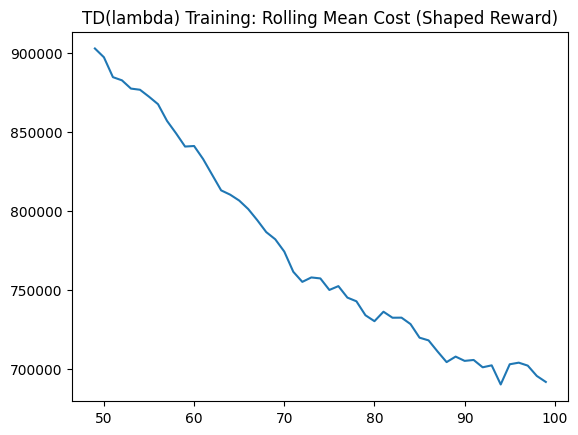

In [50]:
# @title Helper functions and TD(lambda) Training
def continuous_state_normalization(obs: dict) -> np.ndarray:
    '''Normalizes and flattens the raw observation dictionary into a continuous vector.'''
    inventory_norm = obs['inventory'].astype(float) / 500.0
    pipeline_norm = obs['arrival_pipeline'].flatten().astype(float) / 200.0
    demand_history_norm = obs['demand_history'].flatten().astype(float) / 100.0
    day_norm = obs['day'].astype(float) / 50.0
    capacity_utilisation_norm = obs['capacity_utilisation'].astype(float)
    return np.concatenate([inventory_norm, pipeline_norm, demand_history_norm, day_norm, capacity_utilisation_norm], axis=0)

def discrete_state_aggregation(obs: dict) -> int:
    '''Aggregates continuous state variables into a single discrete state index.'''
    inventory_bins = []
    for i in range(N):
        if obs['inventory'][i] < 30: inventory_bins.append(0)
        elif obs['inventory'][i] < 80: inventory_bins.append(1)
        else: inventory_bins.append(2)
    inventory_state = inventory_bins[0] * 9 + inventory_bins[1] * 3 + inventory_bins[2] * 1

    pipeline_bins = []
    for i in range(N):
        total_pipeline_sum = obs['arrival_pipeline'][i].sum()
        if total_pipeline_sum < 30: pipeline_bins.append(0)
        else: pipeline_bins.append(1)
    pipeline_state = pipeline_bins[0] * 4 + pipeline_bins[1] * 2 + pipeline_bins[2] * 1

    day = obs['day'][0]
    day_state = 0 if day <= 15 else (1 if day <= 35 else 2)
    return inventory_state * (8 * 3) + pipeline_state * 3 + day_state

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    return [int(QUANTITIES[idx]) for idx in action_indices]

NUM_DISCRETE_STATES = 27 * 8 * 3
NUM_TOTAL_ACTIONS = 1331
LAMBDA = 0.80
ALPHA = 0.02
GAMMA = 0.99
EPSILON = 1.0
MIN_EPSILON = 0.05
EPSILON_DECAY = 0.995

def train_td_lambda(env, q_table, num_episodes, alpha, gamma, epsilon, epsilon_decay, min_epsilon, lam):
    'Trains a TD(lambda) agent using shaped rewards.'
    episode_costs = []
    current_epsilon = epsilon
    e_table = np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS))

    for episode in range(num_episodes):
        observation, _ = env.reset() if episode > 0 else env.reset(seed=SEED)
        state_t = discrete_state_aggregation(observation)
        e_table.fill(0)

        if np.random.rand() < current_epsilon: action_t_idx = np.random.randint(0, NUM_TOTAL_ACTIONS)
        else: action_t_idx = np.argmax(q_table[state_t, :])

        terminated, truncated, episode_total_cost = False, False, 0.0
        while not terminated and not truncated:
            multi_discrete_action = map_action_index_to_multi_discrete(action_t_idx)
            quantities = action_index_to_quantity(multi_discrete_action)
            env_action = env.quantities_to_action_indices(quantities)

            next_observation, _, terminated, truncated, info = env.step(env_action)
            state_t_plus_1 = discrete_state_aggregation(next_observation)
            episode_total_cost += info['costs']['daily_total']

            # Apply Reward Shaping
            cost_data = calculate_costs_and_reward(
                inventory=next_observation['inventory'],
                inventory_available=observation['inventory'],
                demand=info['demand'],
                orders=np.array(quantities),
                discarded_units=info['discarded_units']
            )
            reward_t = cost_data['base_reward']

            if terminated or truncated:
                action_t_plus_1_idx, q_s_prime_a_prime = None, 0
            else:
                if np.random.rand() < current_epsilon: action_t_plus_1_idx = np.random.randint(0, NUM_TOTAL_ACTIONS)
                else: action_t_plus_1_idx = np.argmax(q_table[state_t_plus_1, :])
                q_s_prime_a_prime = q_table[state_t_plus_1, action_t_plus_1_idx]

            delta = reward_t + gamma * q_s_prime_a_prime - q_table[state_t, action_t_idx]
            e_table = gamma * lam * e_table
            e_table[state_t, action_t_idx] += 1
            q_table += alpha * delta * e_table

            state_t, action_t_idx, observation = state_t_plus_1, action_t_plus_1_idx, next_observation

        episode_costs.append(episode_total_cost)
        current_epsilon = max(min_epsilon, current_epsilon * epsilon_decay)
        if (episode + 1) % 500 == 0: print(f'Episode {episode + 1}/{num_episodes}, Cost: {episode_total_cost:.1f}')

    return q_table, episode_costs

training_env_td_lambda = IndustrialInventoryEnv(student_config=student_config, scenario_mode='random', domain_randomization=True)
trained_td_lambda_q_table, td_lambda_training_episode_costs = train_td_lambda(
    training_env_td_lambda, np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS)),
    TRAINING_EPISODES, ALPHA, GAMMA, EPSILON, EPSILON_DECAY, MIN_EPSILON, LAMBDA
)

plt.plot(pd.Series(td_lambda_training_episode_costs).rolling(50).mean())
plt.title('TD(lambda) Training: Rolling Mean Cost (Shaped Reward)')
plt.show()

In [51]:
def td_lambda_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained Tabular TD(lambda) policy.'
    # The run_policy function from cell v_v7JddBFskP is used here.
    return run_policy(observation)

# Evaluate the Tabular TD(lambda) policy
print('Evaluating Tabular TD(lambda)...')
td_lambda_results = evaluate_policy(td_lambda_policy, student_config)
display(td_lambda_results)

Evaluating Tabular TD(lambda)...


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,1016370.625,161672.060735,0.643,0.749


In [52]:
# @title Save TD with trace model
td_lambda_path = 'td_lambda_q_table_trained.npy'
np.save(td_lambda_path, trained_td_lambda_q_table)
print(f"Trained Tabular TD(lambda) model saved to {td_lambda_path}")

Trained Tabular TD(lambda) model saved to td_lambda_q_table_trained.npy


In [53]:
N = 3 # Number of Products
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = N
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES) # 11 (0 to 100 in steps of 10)
NUM_TOTAL_ACTIONS = NUM_CHOICES_PER_PRODUCT ** NUM_PRODUCTS # 11^3 = 1331
NUM_DISCRETE_STATES = 27 * 8 * N  # From discrete_state_aggregation (Inventory * Pipeline * DayPhase)

# Helper functions (copied for self-containment for the run_policy context)
def discrete_state_aggregation(obs: dict) -> int:
    'Aggregates continuous state variables into a single discrete state index.'
    inventory_bins = []
    for i in range(N):
        if obs['inventory'][i] < 30:
            inventory_bins.append(0) # Low
        elif obs['inventory'][i] < 80:
            inventory_bins.append(1) # Medium
        else:
            inventory_bins.append(2) # High
    inventory_state = inventory_bins[0] * 9 + inventory_bins[1] * 3 + inventory_bins[2] * 1

    pipeline_bins = []
    for i in range(N):
        total_pipeline_sum = obs['arrival_pipeline'][i].sum()
        if total_pipeline_sum < 30:
            pipeline_bins.append(0) # Low
        else:
            pipeline_bins.append(1) # High
    pipeline_state = pipeline_bins[0] * 4 + pipeline_bins[1] * 2 + pipeline_bins[2] * 1

    day = obs['day'][0]
    if day <= 15:
        day_state = 0 # Early
    elif day <= 35:
        day_state = 1 # Mid
    else:
        day_state = 2 # Late

    discrete_state = inventory_state * (8 * 3) + pipeline_state * 3 + day_state
    return discrete_state

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    '''Converts a single integer action index to a MultiDiscrete action tuple.'''
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

# Initialize Q-table with zeros (will be overwritten if model loads successfully)
initial_td_lambda_q_table = np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS))

# Evaluate the policy.
model_path = Path('./td_lambda_q_table_trained.npy')

if model_path.exists():
    try:
        loaded_td_lambda_q_table = np.load(model_path)
        print(f'TD(lambda) Q-table loaded successfully from {model_path}')
    except Exception as e:
        print(f'Error loading TD(lambda) Q-table from {model_path}: {e}')
        print('TD(lambda) Q-table initialized with zeros instead.')
        loaded_td_lambda_q_table = initial_td_lambda_q_table
else:
    print(f'Warning: Model file not found at {model_path}. TD(lambda) Q-table initialized with zeros.')
    print('Please ensure your trained td_lambda_q_table_trained.npy is saved in the correct location.')
    loaded_td_lambda_q_table = initial_td_lambda_q_table

# Main run_policy for evaluation
def run_policy(observation: dict) -> list[int]:
    'Return order quantities for Products 1, 2 and 3 using the trained Tabular TD(lambda) policy.'

    # Get discrete state from observation
    state = discrete_state_aggregation(observation)

    # Choose action with the highest Q-value (exploitation only)
    action_idx = np.argmax(loaded_td_lambda_q_table[state, :])

    # Convert single action index to MultiDiscrete action tuple
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)

    # Convert MultiDiscrete indices to actual quantities
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

TD(lambda) Q-table loaded successfully from td_lambda_q_table_trained.npy


# Final comparison matrix

In [56]:
# Initialize the comparison matrix structure with existing results and placeholders
results = [
    {
        'Technique': 'Tabular Q-Learning',
        'Obs Variables': 'Discretized Inv + Pipeline',
        'Reward Shaping': 'Yes',
        'Avg Cost': q_learning_results['Mean Episode Cost'].iloc[0]
     },
    {
        'Technique': 'Tabular SARSA',
        'Obs Variables': 'Discretized Inv + Pipeline',
        'Reward Shaping': 'Yes',
        'Avg Cost': sarsa_results['Mean Episode Cost'].iloc[0]
    },
    {
        'Technique': 'DQN',
        'Obs Variables': 'Full Vector',
        'Reward Shaping': 'Yes',
        'Avg Cost': dqn_results['Mean Episode Cost'].iloc[0]
    },
    {
        'Technique': 'Double DQN',
        'Obs Variables': 'Full Vector',
        'Reward Shaping': 'Yes',
        'Avg Cost': double_dqn_results['Mean Episode Cost'].iloc[0]
    },
    {
        'Technique': 'PPO',
        'Obs Variables': 'Full Vector',
        'Reward Shaping': 'Yes',
        'Avg Cost': ppo_results['Mean Episode Cost'].iloc[0]
    },
    {
        'Technique': 'A3C',
        'Obs Variables': 'Full Vector',
        'Reward Shaping': 'Yes',
        'Avg Cost': a3c_results['Mean Episode Cost'].iloc[0]
    },
    {
        'Technique': 'Reinforcement',
        'Obs Variables': 'Full Vector',
        'Reward Shaping': 'Yes',
        'Avg Cost': reinforce_results['Mean Episode Cost'].iloc[0]
    },
    {
        'Technique': 'Neural Network based SARSA',
        'Obs Variables': 'Discretized Inv + Pipeline',
        'Reward Shaping': 'No',
        'Avg Cost': nn_sarsa_results['Mean Episode Cost'].iloc[0]
    },
    {
        'Technique': 'TD(λ) with Eligibility Traces',
        'Obs Variables': 'Discretized Inv + Pipeline',
        'Reward Shaping': 'Yes',
        'Avg Cost': td_lambda_results['Mean Episode Cost'].iloc[0]
    }
]

# Convert the results list to a DataFrame and display it
df_results = pd.DataFrame(results)
print('\nFinal Comparison Matrix:')
display(df_results)


Final Comparison Matrix:


,Technique,Obs Variables,Reward Shaping,Avg Cost
0,Tabular Q-Learning,Discretized Inv + Pipeline,Yes,1464074.125
1,Tabular SARSA,Discretized Inv + Pipeline,Yes,1561093.000
2,DQN,Full Vector,Yes,1372177.125
3,Double DQN,Full Vector,Yes,1925388.125
4,PPO,Full Vector,Yes,771621.375
5,A3C,Full Vector,Yes,493272.500
6,Reinforcement,Full Vector,Yes,1494586.000
7,Neural Network based SARSA,Discretized Inv + Pipeline,No,1018061.500
8,TD(λ) with Eligibility Traces,Discretized Inv + Pipeline,Yes,1016370.625


In [57]:
technique_tracker = pd.DataFrame(
    [
        {
            'technique': 'Tabular Q-Learning',
            'main_state_representation': 'Discretized Inv + Pipeline (5*5*5*3=375 states)',
            'important_hyperparameters': 'ALPHA=0.07, GAMMA=0.96, EPSILON=1.0 (decayed to 0.01), EPSILON_DECAY=0.995',
            'local_average_cost': q_learning_results['Mean Episode Cost'].iloc[0] if 'q_learning_results' in locals() else np.nan,
            'public_submission_id': 'V015',
            'public_average_cost': 1622643.00,
            'policy_file': 'policy.py',
            'model_artifact': 'q_table_trained.npy',
        },
        {
            'technique': 'Tabular SARSA',
            'main_state_representation': 'Discretized Inv + Pipeline (5*5*5*3=375 states)',
            'important_hyperparameters': 'ALPHA=0.07, GAMMA=0.96, EPSILON=1.0 (decayed to 0.01), EPSILON_DECAY=0.995',
            'local_average_cost': sarsa_results['Mean Episode Cost'].iloc[0] if 'sarsa_results' in locals() else np.nan,
            'public_submission_id': 'V015',
            'public_average_cost': 1622643.00,
            'policy_file': 'policy.py',
            'model_artifact': 'sarsa_table_trained.npy',
        },
        {
            'technique': 'DQN',
            'main_state_representation': 'Continuous Vector (38 dimensions)',
            'important_hyperparameters': 'DQN_LEARNING_RATE=0.0001, GAMMA=0.98, EPSILON=1.0 (decayed to 0.05), EPSILON_DECAY=0.9995, BATCH_SIZE=128, BUFFER_SIZE=100000, TARGET_UPDATE_FREQ=500',
            'local_average_cost': dqn_results['Mean Episode Cost'].iloc[0] if 'dqn_results' in locals() else np.nan,
            'public_submission_id':  'V015',
            'public_average_cost': 1669395.62,
            'policy_file': 'policy.py',
            'model_artifact': 'dqn_model.pth',
        },
        {
            'technique': 'Double DQN',
            'main_state_representation': 'Continuous Vector (38 dimensions)',
            'important_hyperparameters': 'alpha=0.0001, gamma=0.98, epsilon=1.0 (decayed to 0.05), epsilon_decay=0.9995, batch_size=128, buffer_size=100000, target_update_freq=500',
            'local_average_cost': double_dqn_results['Mean Episode Cost'].iloc[0] if 'double_dqn_results' in locals() else np.nan,
            'public_submission_id':  'V015',
            'public_average_cost': 1614342.62,
            'policy_file': 'policy.py',
            'model_artifact': 'double_dqn_model.pth',
        },
        {
            'technique': 'PPO',
            'main_state_representation': 'Continuous Vector (38 dimensions)',
            'important_hyperparameters': 'PPO_LEARNING_RATE=2e-5, PPO_GAMMA=0.98, PPO_GAE_LAMBDA=0.95, PPO_CLIP_EPSILON=0.1, PPO_EPOCHS=15, PPO_BATCH_SIZE=128, PPO_STEPS_PER_EPISODE=50, PPO_ENTROPY_COEFF=0.02',
            'local_average_cost': ppo_results['Mean Episode Cost'].iloc[0] if 'ppo_results' in locals() else np.nan,
            'public_submission_id':  'V015',
            'public_average_cost': 1248778.88,
            'policy_file': 'policy.py',
            'model_artifact': 'ppo_model.pth',
        },
        {
            'technique': 'A3C',
            'main_state_representation': 'Continuous Vector (38 dimensions)',
            'important_hyperparameters': 'A3C_LEARNING_RATE=0.0003, A3C_GAMMA=0.99, A3C_GAE_LAMBDA=0.95, A3C_ENTROPY_COEFF=0.01, A3C_N_STEPS=20',
            'local_average_cost': a3c_results['Mean Episode Cost'].iloc[0] if 'a3c_results' in locals() else np.nan,
            'public_submission_id':  'V015',
            'public_average_cost': 1061556.88,
            'policy_file': 'policy.py',
            'model_artifact': 'a3c_model.pth',
        },
        {
            'technique': 'Reinforcement with baseline',
            'main_state_representation': 'Continuous Vector (38 dimensions)',
            'important_hyperparameters': 'REINFORCE_ACTOR_LR=5e-4, REINFORCE_CRITIC_LR=2e-3, REINFORCE_GAMMA=0.85, REINFORCE_ENTROPY_COEFF=0.005, REINFORCE_LR_DECAY=0.999, REINFORCE_MIN_LR=1e-6',
            'local_average_cost': reinforce_results['Mean Episode Cost'].iloc[0] if 'reinforce_results' in locals() else np.nan,
            'public_submission_id':  'V015',
            'public_average_cost': 1084109.00,
            'policy_file': 'policy.py',
            'model_artifact': 'reinforce_model.pth',
        },
        {
            'technique': 'Neural Network based SARSA',
            'main_state_representation': 'Continuous Vector (38 dimensions)',
            'important_hyperparameters': 'SARSA_LEARNING_RATE=0.0005, GAMMA=0.99, EPSILON=1.0 (decayed to 0.05), EPSILON_DECAY=0.998, BATCH_SIZE=64, BUFFER_SIZE=100000, TARGET_UPDATE_FREQ=200',
            'local_average_cost': nn_sarsa_results['Mean Episode Cost'].iloc[0] if 'nn_sarsa_results' in locals() else np.nan,
            'public_submission_id':  'V015',
            'public_average_cost': 1332437.75,
            'policy_file': 'policy.py',
            'model_artifact': 'nn_sarsa_model.pth',
        },
        {
            'technique': 'TD(λ) with Eligibility Traces',
            'main_state_representation': 'Discretized Inv + Pipeline (5*5*5*3=375 states)',
            'important_hyperparameters': 'ALPHA=0.02, GAMMA=0.99, EPSILON=1.0 (decayed to 0.05), EPSILON_DECAY=0.995, LAMBDA=0.80',
            'local_average_cost': td_lambda_results['Mean Episode Cost'].iloc[0] if 'td_lambda_results' in locals() else np.nan,
            'public_submission_id':  'V015',
            'public_average_cost': 1622643.00,
            'policy_file': 'policy.py',
            'model_artifact': 'td_lambda_q_table_trained.npy',
        }
    ]
)
technique_tracker

,technique,main_state_representation,important_hyperparameters,local_average_cost,public_submission_id,public_average_cost,policy_file,model_artifact
0,Tabular Q-Learning,Discretized Inv + Pipeline (5*5*5*3=375 states),"ALPHA=0.07, GAMMA=0.96, EPSILON=1.0 (decayed t...",1464074.125,V015,1622643.00,policy.py,q_table_trained.npy
1,Tabular SARSA,Discretized Inv + Pipeline (5*5*5*3=375 states),"ALPHA=0.07, GAMMA=0.96, EPSILON=1.0 (decayed t...",1561093.000,V015,1622643.00,policy.py,sarsa_table_trained.npy
2,DQN,Continuous Vector (38 dimensions),"DQN_LEARNING_RATE=0.0001, GAMMA=0.98, EPSILON=...",1372177.125,V015,1669395.62,policy.py,dqn_model.pth
3,Double DQN,Continuous Vector (38 dimensions),"alpha=0.0001, gamma=0.98, epsilon=1.0 (decayed...",1925388.125,V015,1614342.62,policy.py,double_dqn_model.pth
4,PPO,Continuous Vector (38 dimensions),"PPO_LEARNING_RATE=2e-5, PPO_GAMMA=0.98, PPO_GA...",771621.375,V015,1248778.88,policy.py,ppo_model.pth
5,A3C,Continuous Vector (38 dimensions),"A3C_LEARNING_RATE=0.0003, A3C_GAMMA=0.99, A3C_...",493272.500,V015,1061556.88,policy.py,a3c_model.pth
6,Reinforcement with baseline,Continuous Vector (38 dimensions),"REINFORCE_ACTOR_LR=5e-4, REINFORCE_CRITIC_LR=2...",1494586.000,V015,1084109.00,policy.py,reinforce_model.pth
7,Neural Network based SARSA,Continuous Vector (38 dimensions),"SARSA_LEARNING_RATE=0.0005, GAMMA=0.99, EPSILO...",1018061.500,V015,1332437.75,policy.py,nn_sarsa_model.pth
8,TD(λ) with Eligibility Traces,Discretized Inv + Pipeline (5*5*5*3=375 states),"ALPHA=0.02, GAMMA=0.99, EPSILON=1.0 (decayed t...",1016370.625,V015,1622643.00,policy.py,td_lambda_q_table_trained.npy
